# Readmission for Healthcare Analysis

## Initial Exploration

This notebook loads the dataset and performs initial exploration to understand its structure, variables, and data quality.  

# Team Members

- Michael Ryan: mor23@drexel.edu - Methodology, Analysis, Evaluation & Documentation
- Roy Phelps: rp994@drexel.edu - Data Exploration, Project Setup & Data Analytics
- Shelby Frisbie: sdp94@drexel.edu - Data Exploration and Documentation
- Saad Majid: sm5229@drexel.edu - ML Algorithm & Data Analysis


## GitHub Repository
This project has been uploaded to GitHub and can be found at: https://github.com/royphelps1/hospital-readmission-analysis. 
Please reach out to Roy Phelps to gain access to the repo: rp994@drexel.edu.  It is set to private within our group.  

## Abstract

Hospital readmissions are an important healthcare quality concern because they can affect patient outcomes, resource utilization, and healthcare costs. This project investigates factors associated with hospital readmission using exploratory data analysis and supervised machine learning techniques applied to a synthetic healthcare dataset containing 8,000 patient records.

Exploratory analysis was used to evaluate data quality, examine variable distributions, and identify relationships between patient demographic and clinical characteristics and readmission outcomes. The analysis indicated that previous readmissions, comorbidity burden, and several primary diagnosis categories were among the variables most strongly associated with readmission, while length of stay demonstrated a comparatively weaker relationship.

Three classification approaches were evaluated: Logistic Regression, Decision Tree, and Random Forest. Hyperparameter tuning was applied to the tree-based models to reduce overfitting and improve generalization. A potentially problematic feature, `readmission_risk_score`, was also evaluated for possible data leakage and excluded from the final modeling approach because its construction was undocumented.

Among the final candidate models, Logistic Regression provided the strongest overall combination of predictive performance and interpretability, achieving an accuracy of 81.4%, recall of 95.1%, F1-score of 88.8%, ROC-AUC of 83.9%*, and Average Precision of 94.1% on the held-out test dataset. Model interpretation further identified previous readmissions, comorbidity burden, and several clinical diagnoses as important predictors of readmission.

Overall, the findings demonstrate that meaningful readmission predictions can be generated without relying on the potentially problematic risk-score feature. Logistic Regression was selected as the preferred final model because it combined strong predictive performance with greater interpretability, allowing the analysis to identify patient characteristics associated with elevated readmission risk. Because the dataset is synthetic, the findings should be interpreted as a demonstration of data science methodology rather than clinically validated evidence.


# Phase 1
## 1. Introduction

### 1.1 Project Motivation

Hospital readmissions are an important quality metric in healthcare because they often indicate complications, insufficient follow-up care, or ineffective discharge planning. Unplanned readmissions are associated with poorer patient outcomes, increased healthcare costs, and greater strain on hospital resources. Understanding the factors that contribute to patient readmission can help healthcare providers identify high-risk patients, improve discharge planning, and develop targeted interventions that enhance patient care while reducing unnecessary hospital utilization.

### 1.2 Research Problem

The objective of this project is to investigate which patient demographic, clinical, and hospitalization characteristics are associated with 30-day hospital readmissions. Using exploratory data analysis (EDA), this study examines relationships among patient variables to identify patterns and potential predictors of readmission risk. Although the dataset used in this project is synthetic and intended for educational purposes, it provides a realistic representation of healthcare data that is well suited for exploring analytical techniques and establishing a foundation for predictive modeling.

### 1.3 Research Questions

This project seeks to answer the following research questions:

1. Which patient characteristics are most strongly associated with 30-day hospital readmissions?
2. Does the length of a patient's hospital stay influence the likelihood of readmission?
3. How do previous hospital readmissions relate to future readmission outcomes?
4. Are certain primary diagnoses or clinical conditions associated with higher readmission rates?
5. Which patient variables appear to be the most informative for predicting hospital readmission risk?

### 1.4 Project Objectives

To address these research questions, this project:

* Evaluates the quality, structure, and completeness of the hospital readmission dataset.
* Performs exploratory data analysis using descriptive statistics and data visualization techniques.
* Identifies trends, relationships, and potential predictors associated with patient readmissions.
* Develops and compares multiple machine learning classification models.
* Evaluates model performance using accuracy, precision, recall, F1-score, ROC-AUC, Average Precision, and confusion matrices.
* Investigates the potential for data leakage associated with `readmission_risk_score`.
* Identifies the most informative predictors of hospital readmission using model interpretation techniques.
* Selects a final predictive model based on predictive performance, generalization, and interpretability.


## 2. Description of the Dataset

### 2.1 Dataset Source

The dataset used in this project is the Hospital Patient Readmission Dataset, obtained from Kaggle:

Source: https://www.kaggle.com/datasets/mohamedasak/hospital-patient-readmission-dataset

The dataset was selected because it contains a broad range of demographic, clinical, and hospitalization variables that are relevant to studying hospital readmissions. Although the dataset is synthetic and intended for educational purposes, it closely resembles real-world healthcare data and provides an appropriate foundation for exploratory analysis and predictive modeling.

### 2.2 Dataset Overview

The dataset consists of individual patient records that include demographic information, hospitalization details, clinical characteristics, and readmission outcomes. These variables provide multiple perspectives for exploring factors that may influence whether a patient is readmitted within 30 days of discharge.

The dataset includes the following features:

- patient id
- admission date
- season
- age
- gender
- region
- primary diagnosis
- comorbidities count **(condition that the patient has, ex: stroke, hypertension etc..)**
- length of stay
- treatement type
- medications count
- follow up visits prev. year
- insurance type
- discharge disposition
- readmission risk score
- label **(readmitted in the past 30 days binary, 1 = yes, 0 = no)**

The target variable for this project is the patient's 30-day hospital readmission outcome, represented by `label`, where 1 indicates that the patient was readmitted and 0 indicates that the patient was not readmitted. This binary outcome is used as the target variable throughout the supervised classification analysis.

#### Dataset Characteristics Table

| Characteristic       |  Value |
| -------------------- | -----: |
| Observations         | 50,000 |
| Variables            |     16 |
| Numerical Features   |      8 |
| Categorical Features |      8 |
| Missing Values       |      0 |
| Duplicate Records    |      0 |
| Target Variable      |  Label |


## 3. Exploratory Data Analysis

The exploratory data analysis (EDA) evaluates data quality, summarizes variable distributions, identifies potential anomalies, and explores relationships between patient characteristics and hospital readmission outcomes. The insights obtained during this stage inform feature selection, preprocessing decisions, model development, and interpretation during the predictive modeling analysis.

In [457]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Uncomment for first install
# !pip install openpyxl

In [458]:
# Save images in the image folder initiation 
from pathlib import Path

# Project folders
PROJECT_ROOT = Path.cwd().parent
IMAGE_DIR = PROJECT_ROOT / "images"

IMAGE_DIR.mkdir(exist_ok=True)

In [459]:
# Read in the dataset and view the first 5 entries
df = pd.read_csv("../data/raw/hospital_readmission_dataset.csv")
df.head()

,patient_id,admission_date,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,prev_readmissions,insurance_type,discharge_disposition,readmission_risk_score,label
0,P00001,2022-04-14,Spring,66,Male,South,Diabetes,5,6,Interventional,8,6,1,Medicare,Home Health,0.92,1
1,P00002,2021-09-19,Fall,55,Male,South,Diabetes,4,6,Interventional,6,4,3,Private,Home Health,0.88,1
2,P00003,2023-04-12,Spring,69,Female,West,Hypertension,6,8,Medical,9,6,2,Medicare,Skilled Nursing,0.97,1
3,P00004,2023-08-14,Summer,83,Male,South,Stroke,6,11,Medical,11,4,2,Medicare,Skilled Nursing,0.97,1
4,P00005,2021-11-05,Fall,54,Female,North,Stroke,4,10,Medical,6,2,1,Uninsured,Home Health,0.83,1


## 4. Dataset Structure

We start by examining the size, structure, metrics, missing values of the dataset

In [460]:
# Dataset shape
df.shape

(8000, 17)

In [461]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 8000 non-null   object 
 1   admission_date             8000 non-null   object 
 2   season                     8000 non-null   object 
 3   age                        8000 non-null   int64  
 4   gender                     8000 non-null   object 
 5   region                     8000 non-null   object 
 6   primary_diagnosis          8000 non-null   object 
 7   comorbidities_count        8000 non-null   int64  
 8   length_of_stay             8000 non-null   int64  
 9   treatment_type             8000 non-null   object 
 10  medications_count          8000 non-null   int64  
 11  followup_visits_last_year  8000 non-null   int64  
 12  prev_readmissions          8000 non-null   int64  
 13  insurance_type             8000 non-null   objec

In [462]:
# Dataset metrics
df.describe()

,age,comorbidities_count,length_of_stay,medications_count,followup_visits_last_year,prev_readmissions,readmission_risk_score,label
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.00000,8000.000000,8000.000000
mean,57.411625,4.318500,7.789125,7.475750,3.638125,1.57250,0.776937,0.772875
std,16.724388,1.358046,1.930252,2.287917,1.630415,0.89196,0.219885,0.419000
min,18.000000,1.000000,3.000000,2.000000,0.000000,0.00000,0.070000,0.000000
25%,46.000000,3.000000,6.000000,6.000000,2.000000,1.00000,0.630000,1.000000
50%,57.000000,4.000000,8.000000,8.000000,4.000000,1.00000,0.860000,1.000000
75%,69.000000,5.000000,9.000000,9.000000,4.000000,2.00000,0.970000,1.000000
max,95.000000,10.000000,15.000000,18.000000,10.000000,5.00000,0.970000,1.000000


In [463]:
# Check missing values
df.isnull().sum()

patient_id                   0
admission_date               0
season                       0
age                          0
gender                       0
region                       0
primary_diagnosis            0
comorbidities_count          0
length_of_stay               0
treatment_type               0
medications_count            0
followup_visits_last_year    0
prev_readmissions            0
insurance_type               0
discharge_disposition        0
readmission_risk_score       0
label                        0
dtype: int64

In [464]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

### Interpretation: Missing Vales
No missing values were identified within the dataset. Because every observation contains complete information, no additional preprocessing such as imputation or record removal is required prior to model development.

The descriptive statistics provide a summary of the numerical variables within the dataset. These statistics allow us to better understand the distribution, variability, and range of each feature while identifying potential outliers that may require further investigation.

No duplicate records were identified. This indicates that each patient encounter appears to represent a unique observation, reducing the likelihood of duplicated information influencing the analysis.

### 4.1 Basic Demographic Exploration

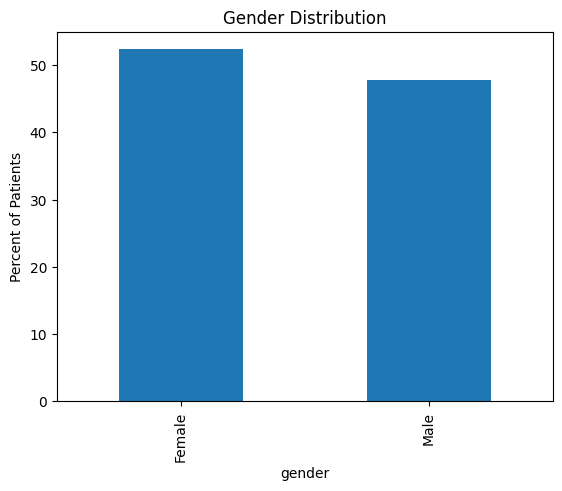

In [465]:
# gender
# slightly more females
gender_n = df["gender"].value_counts()
gender_percent = df["gender"].value_counts(normalize=True) * 100

gender_percent.plot(
    kind="bar",
    title="Gender Distribution",
    ylabel="Percent of Patients"
)


plt.savefig(
    IMAGE_DIR / "Gender Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

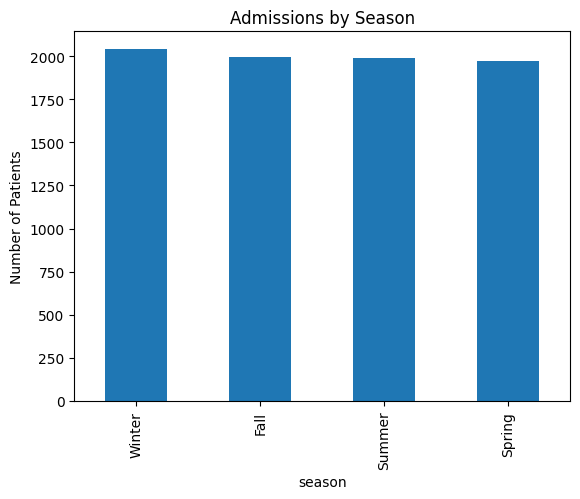

In [466]:
# season is evenly distributed, probably because it is synthetic
season_n = df["season"].value_counts()
season_percent = df["season"].value_counts(normalize=True) * 100

season_n.plot(
    kind="bar",
    title="Admissions by Season",
    ylabel="Number of Patients"
)

plt.savefig(
    IMAGE_DIR / "Admissions by Season.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

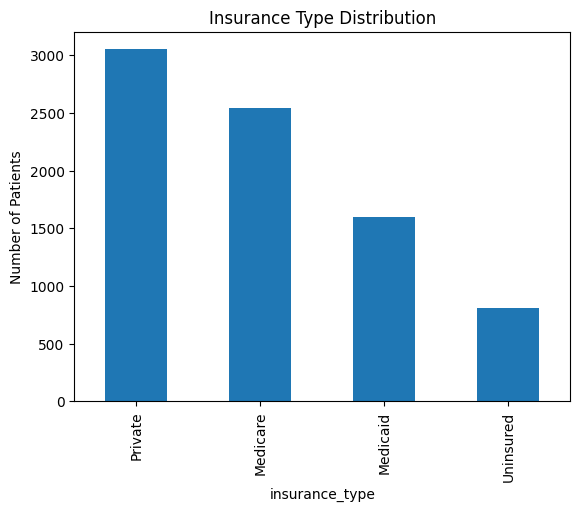

In [467]:
# insurance type

# mostly private and medicare

insurance_n = df["insurance_type"].value_counts()
insurance_percent = df["insurance_type"].value_counts(normalize=True) * 100

insurance_n.plot(
    kind="bar",
    title="Insurance Type Distribution",
    ylabel="Number of Patients"
)


plt.savefig(
    IMAGE_DIR / "Insurance Type Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [468]:
# create age groups and look at insurance type by age group

# starts at 18 years old

bins = [0, 30, 45, 60, 75, 100]
groups = ["18-30", "31-45", "46-60", "61-75", "76+"]

df["age_group"] = pd.cut(df["age"], bins=bins, labels=groups)

insurance_age_pct = pd.crosstab(
    df["age_group"],
    df["insurance_type"],
    normalize="index"
) * 100

print(insurance_age_pct.round(1))

insurance_type  Medicaid  Medicare  Private  Uninsured
age_group                                             
18-30               33.8       0.0     54.1       12.2
31-45               28.0       0.0     57.1       14.8
46-60               29.0       0.0     55.8       15.3
61-75               11.9      60.4     21.9        5.8
76+                  0.0     100.0      0.0        0.0


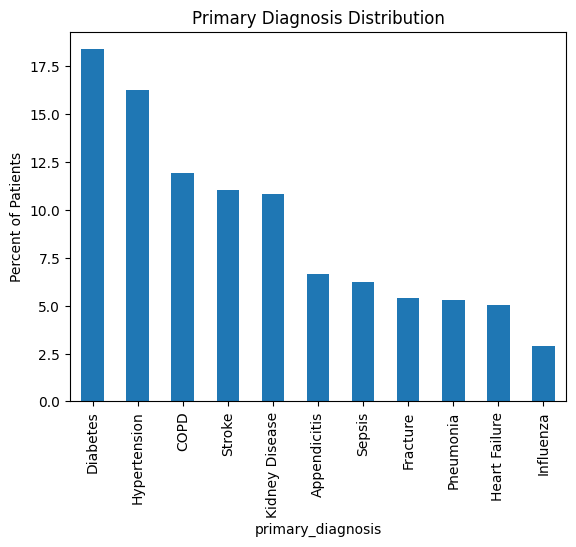

In [469]:
# primary diagnosis
diagnosis_n = df["primary_diagnosis"].value_counts()
diagnosis_percent = df["primary_diagnosis"].value_counts(normalize=True) * 100

diagnosis_percent.plot(
    kind="bar",
    title="Primary Diagnosis Distribution",
    ylabel="Percent of Patients"
)


plt.savefig(
    IMAGE_DIR / "Primary Diagnosis Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation: Demographic



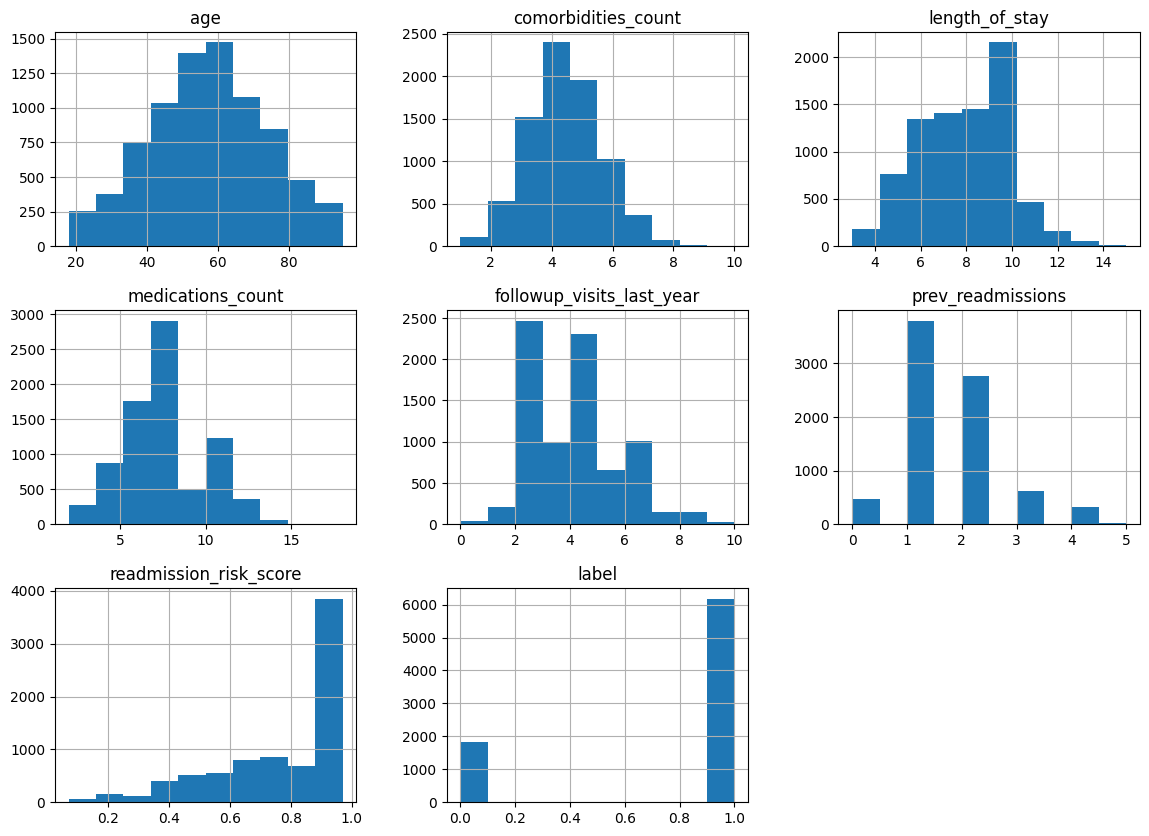

In [470]:
# Histograms for numaric values
df.hist(figsize=(14,10))

plt.savefig(
    IMAGE_DIR / "Histograms.png",
    dpi=300,
    bbox_inches="tight"
)

### Interpretation: Distributions Analysis

The histograms illustrate the distributions of the numerical variables. Several variables appear approximately normally distributed while others exhibit skewness or clustering around common values. Understanding these distributions will assist with selecting appropriate preprocessing techniques and predictive models.

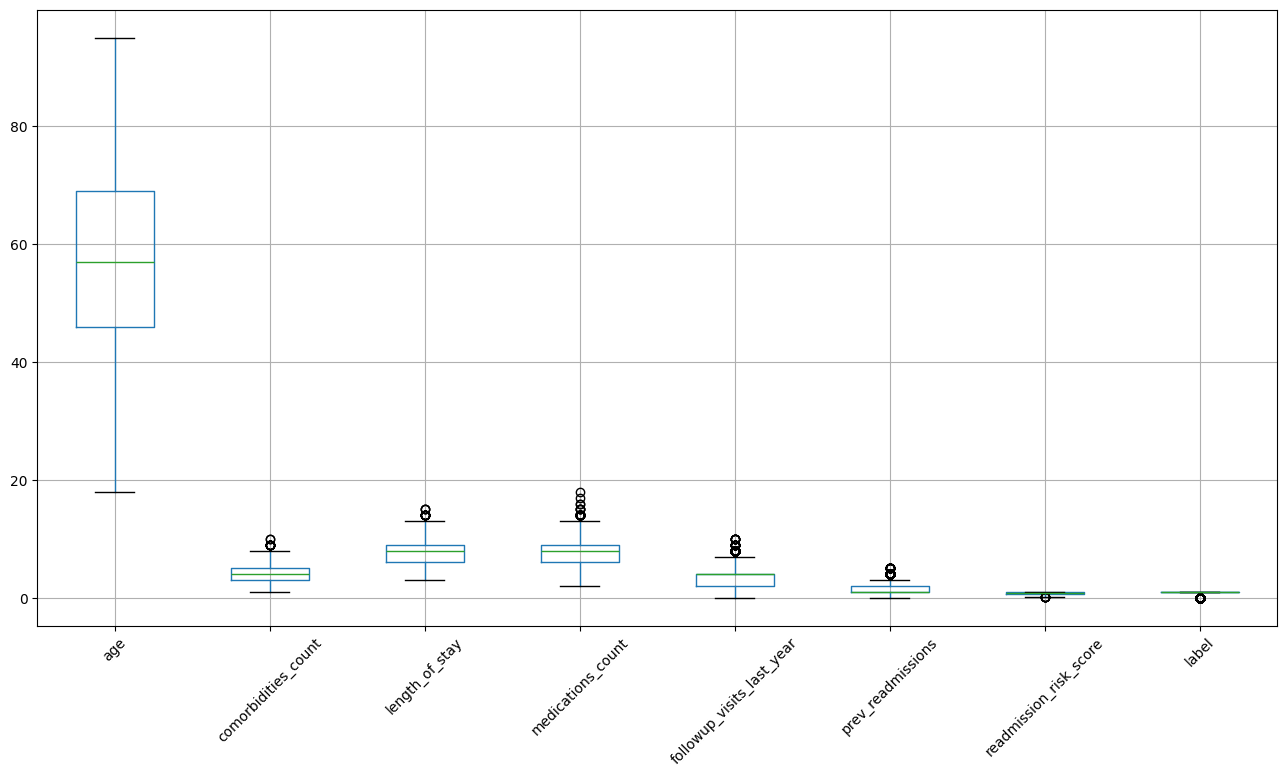

In [471]:
# Box plots of nnumeric values

df.boxplot(figsize=(16,8))
plt.xticks(rotation=45)

plt.savefig(
    IMAGE_DIR / "Box Plots.png",
    dpi=300,
    bbox_inches="tight"
)

### Interpretation: Boxplots Analysis

The boxplots provide a summary of the distribution, median, variability, and potential outliers for each numerical variable in the dataset. The median values (green lines) indicate the central tendency of each feature, while the boxes represent the interquartile range (IQR), showing where the middle 50% of observations fall. The whiskers extend to observations within 1.5 times the IQR, and points beyond the whiskers represent potential outliers.

The **age** variable exhibits the greatest variability, reflecting a broad range of patient ages included in the dataset. Several variables, including **comorbidities_count**, **length_of_stay**, **medications_count**, **followup_visits_last_year**, and **prev_readmissions**, contain observations outside the whiskers. These values likely represent patients with more complex medical histories or increased healthcare utilization rather than data entry errors.

The **readmission_risk_score** and **label** variables display relatively little variation because both are constrained by their respective scales. The binary nature of the **label** variable (0 = not readmitted, 1 = readmitted) naturally limits its distribution.

Overall, the boxplots indicate that while several variables contain potential outliers, these observations appear to be clinically plausible and may represent important high-risk patient populations. Therefore, these values was retained for further investigation during the machine learning phase rather than removed during preprocessing.


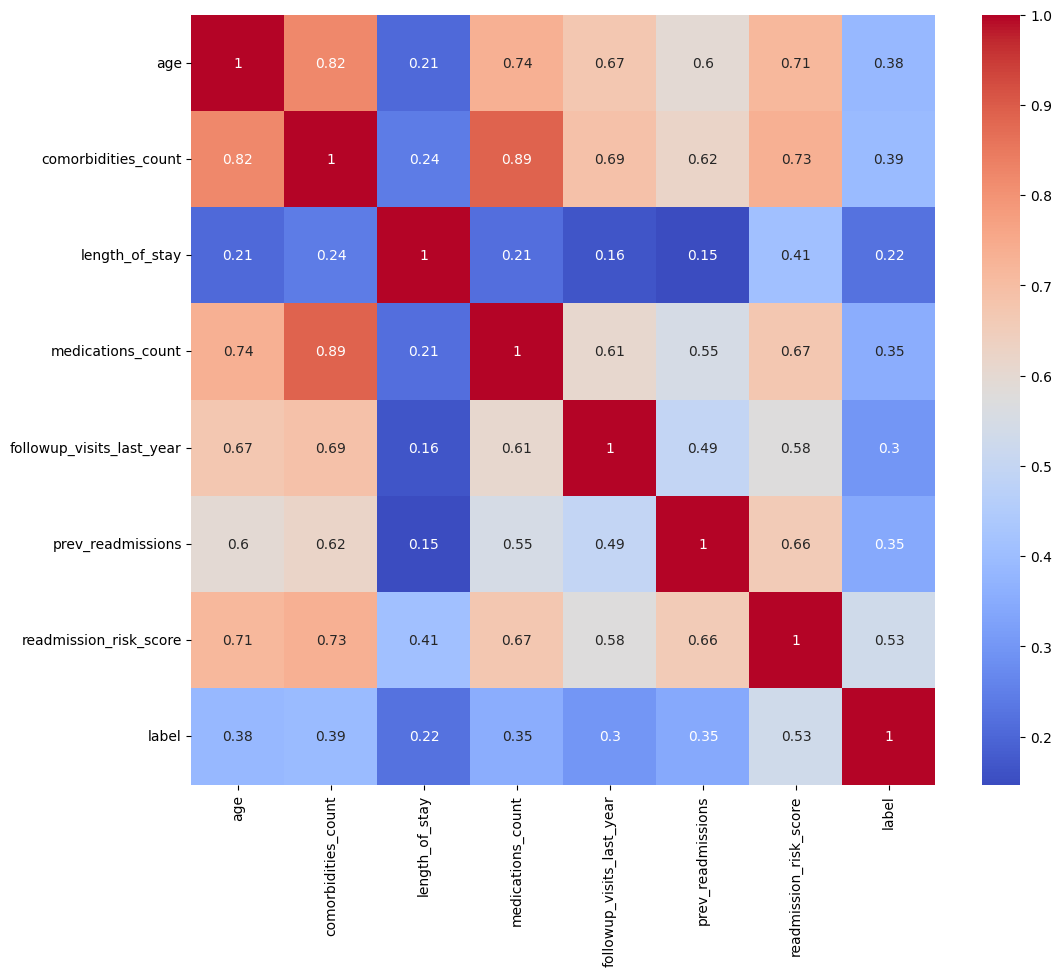

In [472]:
# Correlation matrix to see which varables are moving togeather
# Instll seaborn, uncomment if needed
#%pip install seaborn

import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.savefig(
    IMAGE_DIR / "Correlation Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

### Interpretation: Heatmaps Analysis

The correlation heatmap illustrates the strength of the linear relationships between the numerical variables in the dataset. Correlation coefficients range from **-1** (strong negative relationship) to **1** (strong positive relationship), with values closer to zero indicating little or no linear relationship.

Several variables exhibit strong positive correlations. The strongest relationship is between **comorbidities_count** and **medications_count** (0.89), suggesting that patients with more underlying medical conditions typically require a greater number of medications. Additionally, **age** is strongly correlated with **comorbidities_count** (0.82), indicating that older patients tend to have more chronic health conditions.

The target variable, **label** (30-day readmission), demonstrates its strongest relationship with **readmission_risk_score** (0.53), followed by weaker positive correlations with **comorbidities_count** (0.39), **age** (0.38), **medications_count** (0.35), and **previous_readmissions** (0.35). These findings suggest that patients with higher clinical risk scores, multiple medical conditions, and a history of previous admissions are more likely to experience hospital readmission.

Most other relationships are moderate or weak. For example, **length_of_stay** has relatively low correlations with the target variable (0.22) and with most other features, indicating that hospital stay duration alone may not be a strong predictor of readmission within this dataset.

Overall, the heatmap indicates that several variables are associated with one another, particularly those related to patient health status. These relationships will help guide feature selection during the machine learning phase while also highlighting variables that may exhibit multicollinearity.

Although several variables are highly correlated with one another (for example, age, comorbidities_count, and medications_count), none exhibit perfect correlation. These features was evaluated further during feature selection to determine whether highly correlated predictors should be retained, transformed, or removed to reduce multicollinearity.

In [473]:
# Relationship Between Comorbidities and Hospital Readmission

pd.crosstab(
    df['comorbidities_count'],
    df['label'],
    normalize='index'
)

label,0,1
comorbidities_count,,
1,0.785714,0.214286
2,0.610487,0.389513
3,0.386842,0.613158
4,0.249479,0.750521
5,0.082143,0.917857
6,0.038198,0.961802
7,0.037736,0.962264
8,0.028571,0.971429
9,0.076923,0.923077


### Interpretation: Comorbidities and Readmission

This cross-tabulation summarizes the relationship between the number of patient comorbidities and 30-day hospital readmission. Each row represents a specific number of comorbidities, while the values indicate the proportion of patients who were not readmitted (label = 0) and those who were readmitted (label = 1).

A clear trend is observed throughout the table. As the number of comorbidities increases, the proportion of patients who are readmitted also increases. Patients with only one comorbidity have approximately a **21%** readmission rate, whereas patients with five or more comorbidities experience readmission rates greater than **90%**. Patients with ten recorded comorbidities were readmitted in every observed case within this dataset.

These findings suggest that the number of comorbidities is strongly associated with hospital readmission and may be an important predictive feature during model development. Clinically, this relationship is reasonable because patients with multiple chronic health conditions often require more complex care and are at greater risk for complications following discharge.

Although this relationship is compelling, it should be interpreted cautiously because the dataset is synthetic. Additional analysis using real-world healthcare data would be necessary to determine whether this pattern generalizes to actual patient populations.

In [474]:
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True) * 100)

label
1    6183
0    1817
Name: count, dtype: int64
label
1    77.2875
0    22.7125
Name: proportion, dtype: float64


### Interpretation: Proportion Analysis

The target variable represents whether a patient was readmitted within 30 days of discharge, where 1 indicates a readmission and 0 indicates no readmission. Examining the class distribution is an important step because it helps determine whether the dataset is balanced and whether additional preprocessing techniques may be required during model development.

The dataset contains 6,183 patients (77.29%) who were readmitted and 1,817 patients (22.71%) who were not readmitted. This indicates that the target variable is moderately imbalanced, with the majority of observations belonging to the readmitted class.

Although the imbalance is not severe, relying solely on accuracy could provide an incomplete assessment of predictive performance. Therefore, the machine learning models are evaluated using multiple complementary metrics, including precision, recall, F1-score, ROC-AUC, Average Precision, and confusion matrices.

Overall, the target distribution is suitable for supervised binary classification, although the class imbalance is considered when interpreting model performance.

## 5. Potential Stakeholders

The findings from this analysis may benefit several healthcare stakeholders, including:

- Hospital administrators seeking to reduce readmission rates and improve quality metrics.
- Physicians responsible for discharge planning and patient follow-up.
- Care coordinators identifying patients requiring additional support after discharge.
- Healthcare researchers studying factors associated with patient readmissions.
- Insurance providers interested in reducing avoidable healthcare costs.

Each stakeholder may use the results differently, but all share a common interest in improving patient outcomes while reducing unnecessary hospital readmissions.

## 6. Potential Application

The long-term objective of this project is to develop a predictive model capable of estimating the likelihood of a patient's readmission within 30 days of discharge. Such a model could be incorporated into electronic health record systems to identify high-risk patients before discharge, allowing healthcare providers to implement additional interventions such as follow-up appointments, medication reviews, or case management.

## 7. Dataset Selection and Justification

This dataset was selected because it contains a sufficient number of observations and a diverse collection of demographic and clinical variables relevant to hospital readmissions. The dataset contains no missing values or duplicate records and provides an appropriate foundation for exploratory data analysis and predictive modeling.

Additionally, the binary target variable makes the dataset well suited for supervised classification techniques that was explored in later phases of this project.

## 8. Limitations

Several limitations should be considered when interpreting the results of this analysis.

- The dataset is synthetic and may not fully represent real-world hospital populations.
- Some important clinical variables may not be available, including laboratory values and physician notes.
- The methodology used to generate the synthetic data is unknown.
- The variable `readmission_risk_score` may introduce data leakage if it incorporates information unavailable at prediction time.
- Findings from this analysis should therefore be interpreted as exploratory rather than directly applicable to clinical decision making.

## 9. Target Audience and Dissemination

The intended audience for this analysis includes healthcare administrators, clinicians, quality improvement teams, and healthcare researchers. Results may be communicated through technical reports, interactive dashboards, research presentations, or clinical decision support systems. The ultimate goal is to provide actionable insights that support improved patient outcomes and reduced hospital readmissions.

## 10. Phase I Summary

Overall, the exploratory data analysis demonstrated that the selected dataset is suitable for continued investigation into hospital readmissions. The dataset is complete, contains no duplicate records, and includes a variety of demographic and clinical variables that may contribute to predicting patient readmission. The findings from Phase I - the exploratory phase - establish a strong foundation for Phase II of the project, where machine learning models ware developed and evaluated to predict 30-day hospital readmissions.

# Bonus: Interactive Data Exploration with Bokeh

While the preceding sections of this notebook present the required exploratory data analysis using traditional static visualizations, modern data science often benefits from interactive visualizations that allow users to explore the data dynamically.

The following visualizations were developed using the **Bokeh** Python library to supplement the exploratory analysis. These interactive charts provide capabilities such as zooming, panning, and hover tooltips, allowing additional exploration of relationships within the hospital readmission dataset.

These visualizations are intended as a complement to the required exploratory analysis and demonstrate an additional approach to communicating analytical findings.

In [475]:
# Using the package Bokha, we create some interacive charts

# Import statements
# If needed, install first:
#%pip install bokeh

from bokeh.io import output_notebook, show
from bokeh.plotting import figure
from bokeh.models import ColumnDataSource, HoverTool, FactorRange
from bokeh.layouts import column
from bokeh.transform import factor_cmap
from bokeh.palettes import Category10
from bokeh.models import LinearColorMapper, ColorBar
from bokeh.palettes import RdBu11


output_notebook()

Loading BokehJS ...

## Interactive bar chart

This bar chart demonstrates the readmission counts by diagnosis.  

In [476]:
# Readmission counts by primary diagnosis

diagnosis_counts = (
    df.groupby(["primary_diagnosis", "label"])
      .size()
      .reset_index(name="count")
)

diagnosis_counts["label_text"] = diagnosis_counts["label"].map({
    0: "Not Readmitted",
    1: "Readmitted"
})

diagnosis_counts["x"] = list(
    zip(diagnosis_counts["primary_diagnosis"], diagnosis_counts["label_text"])
)

source = ColumnDataSource(diagnosis_counts)

p1 = figure(
    x_range=FactorRange(*diagnosis_counts["x"]),
    height=450,
    width=900,
    title="Readmission Counts by Primary Diagnosis",
    toolbar_location="above",
    tools="pan,wheel_zoom,box_zoom,reset,save"
)

p1.vbar(
    x="x",
    top="count",
    width=0.8,
    source=source,
    fill_color=factor_cmap(
        "x",
        palette=Category10[10],
        factors=diagnosis_counts["label_text"].unique(),
        start=1,
        end=2
    )
)

p1.add_tools(HoverTool(tooltips=[
    ("Diagnosis", "@primary_diagnosis"),
    ("Readmission Status", "@label_text"),
    ("Patient Count", "@count")
]))

p1.xaxis.major_label_orientation = 1.0
p1.xaxis.axis_label = "Primary Diagnosis / Readmission Status"
p1.yaxis.axis_label = "Patient Count"

show(p1)



## Interactive Correlation Heatmap

This interactive heatmap displays the correlation between the numeric variables contained within the dataset.

In [477]:
# Interactive correlation heatmap for numeric variables

numeric_df = df.select_dtypes(include=["int64", "float64"])
corr = numeric_df.corr().round(2)

corr_df = corr.stack().reset_index()
corr_df.columns = ["feature_1", "feature_2", "correlation"]

source = ColumnDataSource(corr_df)

features = list(corr.columns)

# Personalized colors for our group
group2_colors = [
    "#2F3E46",   # Slate
    "#354F52",   # Blue Green
    "#52796F",   # Sage
    "#84A98C",   # Moss
    "#CAD2C5",   # Light Stone
    "#DDB892",   # Sand
    "#B08968",   # Cedar
    "#7F5539",   # Walnut
    "#5E3023",   # Mahogany
    "#3A1F16",   # Dark Bark
    "#1B0F0A"    # Espresso
]
mapper = LinearColorMapper(
    palette=group2_colors,
    low=-1,
    high=1
)

p3 = figure(
    title="Correlation Heatmap of Numeric Features",
    x_range=features,
    y_range=list(reversed(features)),
    width=850,
    height=700,
    toolbar_location="above",
    tools="pan,wheel_zoom,box_zoom,reset,save"
)

p3.rect(
    x="feature_1",
    y="feature_2",
    width=1,
    height=1,
    source=source,
    fill_color={"field": "correlation", "transform": mapper},
    line_color="white"
)

p3.add_tools(HoverTool(tooltips=[
    ("Feature 1", "@feature_1"),
    ("Feature 2", "@feature_2"),
    ("Correlation", "@correlation")
]))

color_bar = ColorBar(
    color_mapper=mapper,
    label_standoff=12,
    location=(0, 0),
    title="Correlation"
)

p3.add_layout(color_bar, "right")

p3.xaxis.major_label_orientation = 1.0

show(p3)



# Phase II

## 1. Predictive Modeling

The exploratory data analysis provided insight into the structure, quality, and characteristics of the hospital readmission dataset. During the analysis, variable distributions, relationships between features, class imbalance, and the potential for data leakage were identified.

The objective of Phase II is to determine whether the available patient characteristics can be used to predict 30-day hospital readmission and to compare multiple classification approaches.

Three classification approaches are evaluated: Logistic Regression, Decision Tree, and Random Forest. Model performance is assessed using accuracy, precision, recall, F1-score, ROC-AUC, Average Precision, confusion matrices, and Precision-Recall analysis. Cross-validation and hyperparameter tuning are also used to evaluate and improve the generalization of the tree-based models.

The exploratory analysis identified `readmission_risk_score` as a potential source of data leakage because its construction is undocumented. Its effect is therefore evaluated explicitly before selecting the final modeling feature set.


### 1.1 Import Required Libraries

In [478]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Data preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay
)

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

### 1.2 Feature Selection Considerations

During the exploratory data analysis, one feature was identified that warrants additional investigation: `readmission_risk_score`.

This variable appears to represent an overall assessment of a patient's likelihood of hospital readmission. However, the methodology used to calculate this score is not documented. As a result, it is unclear whether the score was derived using only information available at the time of patient discharge or whether it incorporates information that would only become available after the prediction would normally be made.

If the latter is true, including this feature during model training could introduce **data leakage**, resulting in overly optimistic model performance that would not generalize to real-world clinical settings.

To investigate the potential impact of this feature, two predictive modeling approaches were evaluated:

- **Model A:** Includes all available predictor variables, including `readmission_risk_score`.
- **Model B:** Excludes `readmission_risk_score` to evaluate how well the remaining demographic and clinical variables predict hospital readmission.

The performance of both models were compared using the same evaluation metrics. This comparison helped to determine whether the inclusion of `readmission_risk_score` provides legitimate predictive value or whether it artificially improves model performance due to information leakage.

Because this dataset is synthetic, the origin and calculation of `readmission_risk_score` are unknown. Rather than assuming the feature is either appropriate or inappropriate for predictive modeling, both approaches were implemented and evaluated. The results of this comparison informed the final feature set used throughout the remainder of the analysis.

### 1.3 Review the Dataset

Before preparing the data for machine learning, the dataset is reviewed to confirm its structure, column data types, and completeness. This step helps identify any remaining issues that may need to be addressed before model training begins.

In [479]:
# Display the first five rows of the dataset
df.head()

# Display the number of rows and columns
print("Dataset shape:", df.shape)

# Display column names and data types
df.info()

# Display summary statistics for numerical and categorical columns
df.describe(include="all")

Dataset shape: (8000, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   patient_id                 8000 non-null   object  
 1   admission_date             8000 non-null   object  
 2   season                     8000 non-null   object  
 3   age                        8000 non-null   int64   
 4   gender                     8000 non-null   object  
 5   region                     8000 non-null   object  
 6   primary_diagnosis          8000 non-null   object  
 7   comorbidities_count        8000 non-null   int64   
 8   length_of_stay             8000 non-null   int64   
 9   treatment_type             8000 non-null   object  
 10  medications_count          8000 non-null   int64   
 11  followup_visits_last_year  8000 non-null   int64   
 12  prev_readmissions          8000 non-null   int64   
 13  insuran

,patient_id,admission_date,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,prev_readmissions,insurance_type,discharge_disposition,readmission_risk_score,label,age_group
count,8000,8000,8000,8000.000000,8000,8000,8000,8000.000000,8000.000000,8000,8000.000000,8000.000000,8000.00000,8000,8000,8000.000000,8000.000000,8000
unique,8000,1092,4,NaN,2,5,11,NaN,NaN,4,NaN,NaN,NaN,4,4,NaN,NaN,5
top,P00001,2021-04-21,Winter,NaN,Female,South,Diabetes,NaN,NaN,Medical,NaN,NaN,NaN,Private,Home Health,NaN,NaN,46-60
freq,1,16,2041,NaN,4184,1993,1470,NaN,NaN,3588,NaN,NaN,NaN,3052,6065,NaN,NaN,2616
mean,NaN,NaN,NaN,57.411625,NaN,NaN,NaN,4.318500,7.789125,NaN,7.475750,3.638125,1.57250,NaN,NaN,0.776937,0.772875,NaN
std,NaN,NaN,NaN,16.724388,NaN,NaN,NaN,1.358046,1.930252,NaN,2.287917,1.630415,0.89196,NaN,NaN,0.219885,0.419000,NaN
min,NaN,NaN,NaN,18.000000,NaN,NaN,NaN,1.000000,3.000000,NaN,2.000000,0.000000,0.00000,NaN,NaN,0.070000,0.000000,NaN
25%,NaN,NaN,NaN,46.000000,NaN,NaN,NaN,3.000000,6.000000,NaN,6.000000,2.000000,1.00000,NaN,NaN,0.630000,1.000000,NaN
50%,NaN,NaN,NaN,57.000000,NaN,NaN,NaN,4.000000,8.000000,NaN,8.000000,4.000000,1.00000,NaN,NaN,0.860000,1.000000,NaN
75%,NaN,NaN,NaN,69.000000,NaN,NaN,NaN,5.000000,9.000000,NaN,9.000000,4.000000,2.00000,NaN,NaN,0.970000,1.000000,NaN


### 1.4 Data Cleaning and Preprocessing

Although the dataset contains no missing values, several preprocessing steps are required before it can be used for machine learning. These include removing variables that do not contribute to prediction, separating the predictor variables from the target variable, and preparing the data for numerical scaling and categorical encoding.

These preprocessing steps help ensure that the machine learning algorithms receive data in a format suitable for training while reducing the likelihood of introducing bias or unnecessary complexity into the models.

In [480]:
# Check for missing values
df.isnull().sum()

patient_id                   0
admission_date               0
season                       0
age                          0
gender                       0
region                       0
primary_diagnosis            0
comorbidities_count          0
length_of_stay               0
treatment_type               0
medications_count            0
followup_visits_last_year    0
prev_readmissions            0
insurance_type               0
discharge_disposition        0
readmission_risk_score       0
label                        0
age_group                    0
dtype: int64

In [481]:
# Display categorical columns
categorical_columns = df.select_dtypes(include=["object", "category"]).columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['patient_id', 'admission_date', 'season', 'gender', 'region',
       'primary_diagnosis', 'treatment_type', 'insurance_type',
       'discharge_disposition', 'age_group'],
      dtype='object')


In [482]:
# Display numerical columns
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

print("Numerical Columns:")
print(numerical_columns)

Numerical Columns:
Index(['age', 'comorbidities_count', 'length_of_stay', 'medications_count',
       'followup_visits_last_year', 'prev_readmissions',
       'readmission_risk_score', 'label'],
      dtype='object')


### 1.5 Select Features and Target

Machine learning models require the predictor variables (features) and the outcome variable (target) to be separated before training.

In this study, the `label` column represents the target variable that the models will learn to predict. Variables that do not contribute meaningful predictive information, such as unique identifiers and raw dates, are removed from the feature set. The remaining variables were used to train and evaluate the predictive models.

In [483]:
# Create the feature matrix by removing unnecessary columns
X = df.drop(columns=[
    "patient_id",
    "admission_date",
    "label",
    "age_group"
])

# Create the target variable
y = df["label"]

# Display the dimensions of X and y
print("Feature matrix (X):", X.shape)
print("Target vector (y):", y.shape)

Feature matrix (X): (8000, 14)
Target vector (y): (8000,)


### 1.6 Split the Data into Training and Testing Sets

Before training a machine learning model, the dataset is divided into separate training and testing subsets. The training data is used to teach the model patterns within the data, while the testing data is reserved for evaluating the model's performance on previously unseen observations.

Separating the data in this manner provides a more realistic assessment of how well the trained model is expected to generalize to new patient records and helps reduce the risk of overfitting.

In [484]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the size of each dataset
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training features: (6400, 14)
Testing features: (1600, 14)
Training labels: (6400,)
Testing labels: (1600,)


### 1.7 Build the Preprocessing Pipeline

Machine learning algorithms require numerical input. Because this dataset contains both numerical and categorical variables, different preprocessing techniques must be applied to each data type before model training.

Categorical variables are converted into numerical representations using one-hot encoding, while numerical variables are standardized to place them on a comparable scale. A preprocessing pipeline is used to automate these steps, ensuring that the same transformations are consistently applied to both the training and testing datasets.

In [485]:
# Define the categorical columns
categorical_features = [
    "season",
    "gender",
    "region",
    "primary_diagnosis",
    "treatment_type",
    "insurance_type",
    "discharge_disposition"
]

# Define the numerical columns
numerical_features = [
    "age",
    "comorbidities_count",
    "length_of_stay",
    "medications_count",
    "followup_visits_last_year",
    "prev_readmissions",
    "readmission_risk_score"
]

# Create the preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print(preprocessor)

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['age', 'comorbidities_count',
                                  'length_of_stay', 'medications_count',
                                  'followup_visits_last_year',
                                  'prev_readmissions',
                                  'readmission_risk_score']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['season', 'gender', 'region',
                                  'primary_diagnosis', 'treatment_type',
                                  'insurance_type', 'discharge_disposition'])])


## 2. Logistic Regression Model

Logistic Regression is selected as the baseline classification model for this study. It is a widely used supervised machine learning algorithm for binary classification problems because it is computationally efficient, interpretable, and provides a strong baseline for comparison with more complex models.

A machine learning pipeline is created by combining the preprocessing steps with the Logistic Regression model. This approach ensures that all preprocessing transformations are automatically applied during both training and prediction, reducing the risk of data leakage and maintaining a consistent workflow.

In [486]:
# Create the machine learning pipeline
logistic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42))
])

# Train the Logistic Regression model
logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


### 2.1 Generate Predictions and Evaluate the Model

After training the Logistic Regression model, predictions are generated using the testing dataset. Because the testing data was not used during model training, it provides an unbiased assessment of the model's ability to generalize to previously unseen patient records.

Several evaluation metrics are calculated to assess model performance, including accuracy, precision, recall, F1-score, ROC-AUC, and the confusion matrix. Together, these metrics provide a comprehensive understanding of the model's predictive performance.

In [487]:
# Generate predictions using the testing dataset
y_pred = logistic_pipeline.predict(X_test)

# Generate predicted probabilities
y_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

In [488]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# Display the evaluation metrics
print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")
print(f"ROC-AUC  : {roc_auc:.3f}")

Accuracy : 0.816
Precision: 0.847
Recall   : 0.930
F1 Score : 0.886
ROC-AUC  : 0.844


**Note:**

The baseline Logistic Regression model demonstrated strong predictive performance across all evaluation metrics. In particular, the model achieved a recall of 93.0%, indicating that it successfully identified the majority of patients who were readmitted. This is an important characteristic in healthcare applications, where failing to identify high-risk patients may result in missed opportunities for early intervention.

Although these results are encouraging, the model currently includes the `readmission_risk_score` feature. Because the origin and calculation of this variable are unknown, a second model excluding this feature was developed later in the analysis to investigate its impact on predictive performance and assess the potential for data leakage.

### 2.2 Confusion Matrix

The confusion matrix provides a detailed summary of the model's classification performance by comparing the predicted outcomes with the actual patient outcomes. Unlike a single evaluation metric, the confusion matrix illustrates the number of correct and incorrect predictions for each class.

This visualization helps identify the types of errors made by the model, providing additional insight into its strengths and limitations when predicting hospital readmissions.

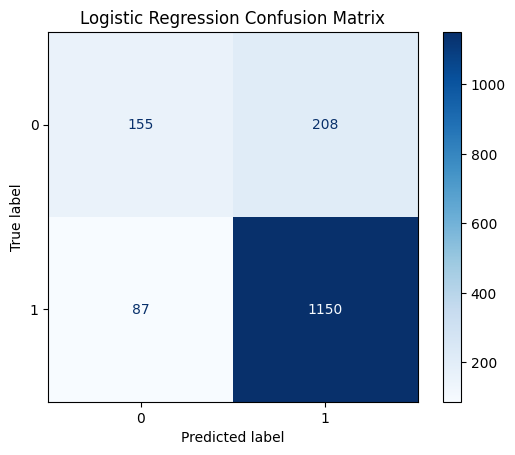

In [489]:
# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")

# Add a title
plt.title("Logistic Regression Confusion Matrix")

# Save the plot to the project's images folder
plt.savefig(
    "../images/Logistic Regression Confusion Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

# Display the plot
plt.show()

### 2.3 Classification Report

The classification report summarizes the predictive performance of the Logistic Regression model for each class separately. In addition to overall accuracy, the report includes precision, recall, F1-score, and support for both classes.

These metrics provide a more detailed understanding of the model's strengths and weaknesses when predicting hospital readmissions.

In [490]:
# Display the classification report
print("Classification Report")
print(classification_report(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

           0       0.64      0.43      0.51       363
           1       0.85      0.93      0.89      1237

    accuracy                           0.82      1600
   macro avg       0.74      0.68      0.70      1600
weighted avg       0.80      0.82      0.80      1600



**Note:**

The classification report confirms the strong performance of the Logistic Regression model across multiple evaluation metrics. In particular, the model achieved high recall for patients who were readmitted, demonstrating its ability to correctly identify the majority of high-risk patients. The weighted average metrics further indicate consistent overall performance despite the class imbalance present in the dataset.

### 2.4 Receiver Operating Characteristic (ROC) Curve

The Receiver Operating Characteristic (ROC) curve provides a graphical evaluation of the Logistic Regression model across a range of classification thresholds. Rather than evaluating the model at a single probability threshold, the ROC curve illustrates the trade-off between the true positive rate (sensitivity) and the false positive rate.

The Area Under the ROC Curve (ROC-AUC) summarizes the model's overall ability to distinguish between patients who were readmitted and those who were not. Values closer to 1.0 indicate stronger classification performance, while a value of 0.5 represents random guessing.

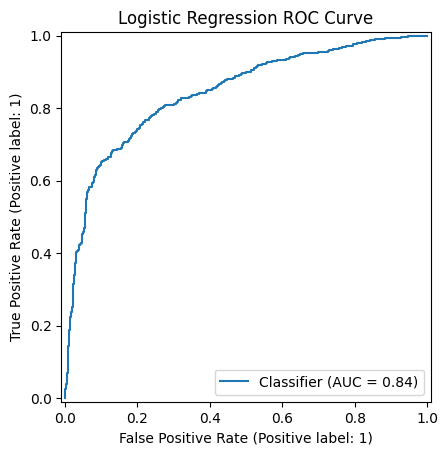

In [491]:
# Display the ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob)

# Add a title
plt.title("Logistic Regression ROC Curve")

# Save the plot to the project's images folder
plt.savefig(
    "../images/Logistic Regression ROC Curve.png",
    dpi=300,
    bbox_inches="tight"
)

# Display the plot
plt.show()

### 2.5 Logistic Regression Model Summary

The Logistic Regression model served as the baseline classification model for predicting hospital readmissions. Overall, the model demonstrated strong predictive performance across multiple evaluation metrics, achieving an accuracy of 81.6%, a precision of 84.7%, a recall of 93.0%, an F1-score of 88.6%, and an ROC-AUC of 84.4%.

One of the model's greatest strengths was its ability to correctly identify patients who were readmitted, as reflected by its high recall. This characteristic is particularly valuable in healthcare applications, where identifying patients at risk of readmission may support earlier intervention and improved patient outcomes.

Although the model produced a number of false positive predictions, these errors may be considered acceptable in many clinical settings because they represent patients who were predicted to be at higher risk than they ultimately were. In contrast, the relatively small number of false negatives suggests that the model successfully identified the majority of patients who were actually readmitted.

While these results provide a strong baseline, the current model includes the `readmission_risk_score` variable. Because the origin and calculation of this feature are unknown, additional models will be developed to determine whether this variable introduces data leakage or artificially improves predictive performance.

### 2.6 Investigation of Potential Data Leakage

The initial Logistic Regression model included `readmission_risk_score`, a feature whose method of calculation is unknown. Because this variable may contain information that would not be available at the time a readmission prediction is made, its inclusion could potentially introduce data leakage.

To investigate its impact, a second Logistic Regression model is developed using the same training and testing observations while excluding `readmission_risk_score`. All other modeling decisions are kept consistent with the original model so that changes in predictive performance can be attributed primarily to the removal of this feature.

The performance of the two models will then be compared using accuracy, precision, recall, F1-score, and ROC-AUC.

In [492]:
# Create new training and testing feature sets
# without the readmission risk score
X_train_no_risk = X_train.drop(
    columns=["readmission_risk_score"]
)

X_test_no_risk = X_test.drop(
    columns=["readmission_risk_score"]
)

# Display the new dimensions
print("Training features without risk score:", X_train_no_risk.shape)
print("Testing features without risk score:", X_test_no_risk.shape)

Training features without risk score: (6400, 13)
Testing features without risk score: (1600, 13)


In [493]:
# Define numerical features without the readmission risk score
numerical_features_no_risk = [
    "age",
    "comorbidities_count",
    "length_of_stay",
    "medications_count",
    "followup_visits_last_year",
    "prev_readmissions"
]

In [494]:
# Create a preprocessing pipeline without the risk score
preprocessor_no_risk = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features_no_risk),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [495]:
# Create the Logistic Regression pipeline without the risk score
logistic_pipeline_no_risk = Pipeline(steps=[
    ("preprocessor", preprocessor_no_risk),
    ("classifier", LogisticRegression(random_state=42))
])

# Train the model
logistic_pipeline_no_risk.fit(X_train_no_risk, y_train)

print("Logistic Regression model without risk score trained successfully! YIPEEE")

Logistic Regression model without risk score trained successfully! YIPEEE


In [496]:
# Generate predictions using the model without the risk score
y_pred_no_risk = logistic_pipeline_no_risk.predict(X_test_no_risk)

# Generate predicted probabilities
y_prob_no_risk = logistic_pipeline_no_risk.predict_proba(
    X_test_no_risk
)[:, 1]

In [497]:
# Calculate evaluation metrics for the model without the risk score
accuracy_no_risk = accuracy_score(y_test, y_pred_no_risk)
precision_no_risk = precision_score(y_test, y_pred_no_risk)
recall_no_risk = recall_score(y_test, y_pred_no_risk)
f1_no_risk = f1_score(y_test, y_pred_no_risk)
roc_auc_no_risk = roc_auc_score(y_test, y_prob_no_risk)

# Display the evaluation metrics
print(f"Accuracy : {accuracy_no_risk:.3f}")
print(f"Precision: {precision_no_risk:.3f}")
print(f"Recall   : {recall_no_risk:.3f}")
print(f"F1 Score : {f1_no_risk:.3f}")
print(f"ROC-AUC  : {roc_auc_no_risk:.3f}")

Accuracy : 0.814
Precision: 0.832
Recall   : 0.951
F1 Score : 0.888
ROC-AUC  : 0.839


**Note:**

Removing `readmission_risk_score` resulted in very little change in the overall performance of the Logistic Regression model. Accuracy decreased only slightly from 81.6% to 81.4%, while ROC-AUC decreased from 0.844 to 0.839. Precision also decreased slightly; however, recall improved from 93.0% to 95.1%, and the F1-score increased slightly from 0.886 to 0.888.

These results suggest that `readmission_risk_score` is not solely responsible for the model's predictive performance and that the remaining demographic and clinical variables contain substantial predictive information. Because the calculation and origin of `readmission_risk_score` remain unknown, the feature was excluded from subsequent models. This provides a more conservative feature set while maintaining comparable predictive performance.

Although this comparison does not establish whether `readmission_risk_score` contains data leakage, it demonstrates that removing the variable does not materially reduce the performance of the Logistic Regression model.

## 3. Decision Tree Classification

Decision Tree classification is a supervised machine learning technique that predicts an outcome by repeatedly dividing the data based on the values of predictor variables. Each division creates branches that separate observations into increasingly similar groups until a prediction can be made.

Unlike Logistic Regression, which estimates the probability of an outcome using a mathematical relationship between the predictor variables and the target, a Decision Tree learns a sequence of decision rules directly from the data.

The Decision Tree model was trained using the final feature set selected during the potential data leakage investigation, which excludes `readmission_risk_score`. Its performance was evaluated using the same metrics as Logistic Regression to allow a consistent comparison between the models.

### 3.1 Build the Decision Tree Pipeline

A preprocessing and modeling pipeline is created for the Decision Tree classifier using the final feature set that excludes `readmission_risk_score`.

Unlike Logistic Regression, Decision Trees do not require numerical features to be standardized because the algorithm makes predictions by splitting observations based on feature values rather than comparing the relative magnitude of model coefficients. Categorical variables must still be converted into numerical representations using one-hot encoding before they can be processed by the model.

In [498]:
# Create the Decision Tree preprocessor
decision_tree_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

# Create the Decision Tree pipeline
decision_tree_pipeline = Pipeline(steps=[
    ("preprocessor", decision_tree_preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

# Train the Decision Tree model
decision_tree_pipeline.fit(X_train_no_risk, y_train)

print("Decision Tree model trained successfully! YAY")

Decision Tree model trained successfully! YAY


### 3.2 Generate Predictions and Evaluate the Decision Tree

After training the Decision Tree classifier, predictions are generated using the testing dataset. The model is evaluated using the same performance metrics applied to Logistic Regression, including accuracy, precision, recall, F1-score, and ROC-AUC.

Using the same testing observations and evaluation metrics allows the performance of the two algorithms to be compared consistently.

In [499]:
# Generate predictions using the Decision Tree model
y_pred_tree = decision_tree_pipeline.predict(X_test_no_risk)

# Generate predicted probabilities for the positive class
y_prob_tree = decision_tree_pipeline.predict_proba(
    X_test_no_risk
)[:, 1]


# Calculate evaluation metrics
accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)
roc_auc_tree = roc_auc_score(y_test, y_prob_tree)


# Display the evaluation metrics
print(f"Accuracy : {accuracy_tree:.3f}")
print(f"Precision: {precision_tree:.3f}")
print(f"Recall   : {recall_tree:.3f}")
print(f"F1 Score : {f1_tree:.3f}")
print(f"ROC-AUC  : {roc_auc_tree:.3f}")

Accuracy : 0.736
Precision: 0.838
Recall   : 0.816
F1 Score : 0.827
ROC-AUC  : 0.640


### 3.3 Check for Decision Tree Overfitting

Decision Trees can become overly complex when allowed to grow without restrictions. This may cause the model to fit the training data extremely well while performing substantially worse on previously unseen observations, a problem known as overfitting.

To investigate whether the initial Decision Tree exhibits this behavior, its accuracy on the training dataset is compared with its accuracy on the testing dataset.

In [500]:
# Generate predictions for the training dataset
y_train_pred_tree = decision_tree_pipeline.predict(
    X_train_no_risk
)

# Calculate training accuracy
tree_train_accuracy = accuracy_score(
    y_train,
    y_train_pred_tree
)

# Calculate testing accuracy
tree_test_accuracy = accuracy_score(
    y_test,
    y_pred_tree
)

# Display the results
print(f"Training Accuracy: {tree_train_accuracy:.3f}")
print(f"Testing Accuracy : {tree_test_accuracy:.3f}")

Training Accuracy: 1.000
Testing Accuracy : 0.736


**Note:**

The initial Decision Tree achieved 100% accuracy on the training dataset but only 73.8% accuracy on the testing dataset. The substantial difference between training and testing performance provides strong evidence that the unrestricted Decision Tree is overfitting the training data.

The model has learned the training observations extremely well but does not generalize as effectively to previously unseen patients. Therefore, the complexity of the Decision Tree was controlled through hyperparameter tuning to reduce overfitting and improve generalization.

### 3.4 Decision Tree Hyperparameter Tuning

The initial Decision Tree demonstrated substantial overfitting, achieving 100% accuracy on the training data but only 73.8% accuracy on the testing data.

To reduce overfitting and improve the model's ability to generalize to unseen observations, several hyperparameters controlling the complexity of the tree were evaluated. These include `max_depth`, `min_samples_split`, and `min_samples_leaf`.

Hyperparameter tuning was performed using cross-validation on the training data. The testing dataset will remain separate and will only be used to evaluate the final selected model.

In [501]:
# Define the hyperparameter values to test
param_grid = {
    "classifier__max_depth": [3, 5, 7, 10, None],
    "classifier__min_samples_split": [2, 10, 20, 50],
    "classifier__min_samples_leaf": [1, 5, 10, 20]
}

# Create the GridSearchCV object
tree_grid_search = GridSearchCV(
    estimator=decision_tree_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

# Train the different Decision Tree combinations
tree_grid_search.fit(X_train_no_risk, y_train)

# Display the best hyperparameter combination
print("Best Parameters:")
print(tree_grid_search.best_params_)

# Display the best cross-validation ROC-AUC score
print(f"\nBest Cross-Validation ROC-AUC: {tree_grid_search.best_score_:.3f}")

Best Parameters:
{'classifier__max_depth': 5, 'classifier__min_samples_leaf': 20, 'classifier__min_samples_split': 2}

Best Cross-Validation ROC-AUC: 0.806


### 3.5 Evaluate the Tuned Decision Tree

Grid search with five-fold cross-validation identified the best-performing Decision Tree hyperparameter combination based on ROC-AUC. The selected model limits the maximum tree depth and requires a minimum number of observations within each leaf, which helps control model complexity and reduce overfitting.

The tuned model is now evaluated using the previously held-out testing dataset to determine whether controlling tree complexity improved its ability to generalize to unseen observations.

In [502]:
# Retrieve the best Decision Tree model found by GridSearchCV
best_tree = tree_grid_search.best_estimator_


# Generate predictions for the testing dataset
y_pred_tree_tuned = best_tree.predict(X_test_no_risk)


# Generate predicted probabilities for the positive class
y_prob_tree_tuned = best_tree.predict_proba(
    X_test_no_risk
)[:, 1]


# Calculate evaluation metrics
accuracy_tree_tuned = accuracy_score(
    y_test,
    y_pred_tree_tuned
)

precision_tree_tuned = precision_score(
    y_test,
    y_pred_tree_tuned
)

recall_tree_tuned = recall_score(
    y_test,
    y_pred_tree_tuned
)

f1_tree_tuned = f1_score(
    y_test,
    y_pred_tree_tuned
)

roc_auc_tree_tuned = roc_auc_score(
    y_test,
    y_prob_tree_tuned
)


# Display the evaluation metrics
print(f"Accuracy : {accuracy_tree_tuned:.3f}")
print(f"Precision: {precision_tree_tuned:.3f}")
print(f"Recall   : {recall_tree_tuned:.3f}")
print(f"F1 Score : {f1_tree_tuned:.3f}")
print(f"ROC-AUC  : {roc_auc_tree_tuned:.3f}")

Accuracy : 0.812
Precision: 0.847
Recall   : 0.924
F1 Score : 0.884
ROC-AUC  : 0.815


In [503]:
# Generate predictions for the training dataset
# using the tuned Decision Tree
y_train_pred_tree_tuned = best_tree.predict(
    X_train_no_risk
)

# Calculate the tuned model's training accuracy
tree_train_accuracy_tuned = accuracy_score(
    y_train,
    y_train_pred_tree_tuned
)

# Display training and testing accuracy
print(f"Tuned Training Accuracy: {tree_train_accuracy_tuned:.3f}")
print(f"Tuned Testing Accuracy : {accuracy_tree_tuned:.3f}")

Tuned Training Accuracy: 0.811
Tuned Testing Accuracy : 0.812


**Note:**

Hyperparameter tuning substantially reduced the overfitting observed in the initial Decision Tree model. Before tuning, the model achieved 100% training accuracy but only 73.8% testing accuracy, indicating that the unrestricted tree had memorized patterns specific to the training data that did not generalize effectively to unseen observations.

After controlling model complexity through cross-validated hyperparameter tuning, training accuracy decreased to 81.1% while testing accuracy increased to 81.2%. The nearly identical training and testing performance indicates that the tuned model generalizes much more effectively to unseen data.

The tuned Decision Tree also improved across the primary evaluation metrics, increasing ROC-AUC from 0.640 to 0.815 and recall from 0.820 to 0.924. These results demonstrate that reducing model complexity significantly improved the Decision Tree's predictive performance and reduced overfitting.

### 3.6 Tuned Decision Tree Confusion Matrix

The confusion matrix provides a detailed view of the tuned Decision Tree's predictions by comparing the predicted readmission outcomes with the actual outcomes in the testing dataset.

This allows the model's true positives, true negatives, false positives, and false negatives to be examined after controlling for the overfitting observed in the initial Decision Tree.

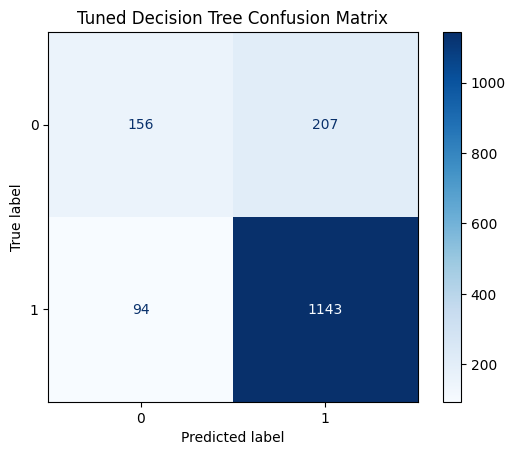

In [504]:
# Create the confusion matrix for the tuned Decision Tree
cm_tree_tuned = confusion_matrix(
    y_test,
    y_pred_tree_tuned
)

# Display the confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=cm_tree_tuned
).plot(cmap="Blues")

# Add a title
plt.title("Tuned Decision Tree Confusion Matrix")

# Save the plot to the project's images folder
plt.savefig(
    "../images/Tuned Decision Tree Confusion Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

# Display the plot
plt.show()

### 3.7 Tuned Decision Tree Classification Report

The classification report summarizes the tuned Decision Tree's precision, recall, F1-score, and support for each outcome class. These results provide additional insight into how effectively the tuned model identifies both readmitted and non-readmitted patients.

In [505]:
# Display the classification report
# for the tuned Decision Tree
print("Tuned Decision Tree Classification Report")

print(
    classification_report(
        y_test,
        y_pred_tree_tuned
    )
)

Tuned Decision Tree Classification Report
              precision    recall  f1-score   support

           0       0.62      0.43      0.51       363
           1       0.85      0.92      0.88      1237

    accuracy                           0.81      1600
   macro avg       0.74      0.68      0.70      1600
weighted avg       0.80      0.81      0.80      1600



### 3.8 Decision Tree Model Summary

The initial Decision Tree model demonstrated substantial overfitting, achieving 100% accuracy on the training dataset but only 73.8% accuracy on the testing dataset. This indicated that the unrestricted tree had learned patterns specific to the training observations that did not generalize effectively to unseen patients.

To address this issue, five-fold cross-validation and grid search were used to evaluate combinations of `max_depth`, `min_samples_split`, and `min_samples_leaf`. The best-performing configuration limited the tree to a maximum depth of 5 and required at least 20 observations in each leaf.

After tuning, testing accuracy improved from 73.8% to 81.2%, recall increased from 82.0% to 92.4%, F1-score increased from 82.9% to 88.4%, and ROC-AUC increased from 0.640 to 0.815. Training accuracy decreased from 100% to 81.1%, becoming nearly identical to the testing accuracy of 81.2%. This substantial reduction in the training-testing performance gap indicates that controlling tree complexity successfully reduced overfitting and improved generalization.

The classification report also revealed differences in performance between the two outcome classes. The tuned model achieved a recall of 92% for patients who were readmitted but only 43% for patients who were not readmitted. This suggests that the model favors identifying readmissions, which should be considered when comparing it with alternative classification models.

Overall, the tuned Decision Tree provides substantially better generalization than the unrestricted model and performs competitively with the Logistic Regression baseline. However, Logistic Regression currently maintains a higher ROC-AUC and recall, while the tuned Decision Tree provides slightly higher precision.

## 4. Random Forest Classification
Random Forest is a supervised machine learning algorithm that builds multiple Decision Trees and combines their predictions to improve overall performance and generalization. Unlike a single Decision Tree, which can be highly sensitive to the training data, Random Forest reduces overfitting by averaging the results of many trees trained on different subsets of the data and features. This makes it a strong candidate for comparing against Logistic Regression and the tuned Decision Tree model.

The Random Forest model will be trained using the final feature set selected during the feature selection investigation, which excludes readmission_risk_score. This ensures that the model is evaluated using only the patient demographic and clinical variables that would reasonably be available in a real-world prediction scenario.

Because the project is focused on identifying a practical and defensible model for predicting hospital readmissions, Random Forest provides an important test of whether a more flexible ensemble method can improve performance beyond the baseline Logistic Regression and the tuned Decision Tree classifier.

### 4.1 Build the Random Forest Pipeline 
A preprocessing and modeling pipeline is created for the Random Forest classifier using the final feature set that excludes readmission_risk_score.

Like the Decision Tree model, Random Forest does not require numerical features to be standardized because tree-based methods split observations based on feature values rather than distance-based calculations. Categorical variables must still be converted into numerical representations using one-hot encoding before they can be processed by the model.

In [506]:
# Create the Random Forest preprocessor
random_forest_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

# Create the Random Forest pipeline
random_forest_pipeline = Pipeline(steps=[
    ("preprocessor", random_forest_preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        n_jobs=-1
    ))
])

# Train the Random Forest model
random_forest_pipeline.fit(X_train_no_risk, y_train)

print("Random Forest model trained successfully!")


Random Forest model trained successfully!


### 4.2 Generate Predictions and Evaluate the Random Forest

After the pipeline is created, the Random Forest model will be trained on the training dataset and evaluated on the testing dataset. The same performance metrics used for Logistic Regression and the Decision Tree will be applied here, including accuracy, precision, recall, F1-score, and ROC-AUC.

Using the same testing observations and evaluation metrics allows the performance of all three models to be compared consistently.


In [507]:
# Generate predictions using the Random Forest model
y_pred_rf = random_forest_pipeline.predict(X_test_no_risk)

# Generate predicted probabilities for the positive class
y_prob_rf = random_forest_pipeline.predict_proba(X_test_no_risk)[:, 1]

# Calculate evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

# Display the evaluation metrics
print(f"Accuracy : {accuracy_rf:.3f}")
print(f"Precision: {precision_rf:.3f}")
print(f"Recall   : {recall_rf:.3f}")
print(f"F1-Score : {f1_rf:.3f}")
print(f"ROC-AUC  : {roc_auc_rf:.3f}")

Accuracy : 0.795
Precision: 0.828
Recall   : 0.927
F1-Score : 0.875
ROC-AUC  : 0.816


### 4.3 Random Forest Classification Report

In [508]:
# Display the classification report
print("Random Forest Classification Report")

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.58      0.34      0.43       363
           1       0.83      0.93      0.87      1237

    accuracy                           0.80      1600
   macro avg       0.70      0.64      0.65      1600
weighted avg       0.77      0.80      0.77      1600



### 4.4 Random Forest Confusion Matrix

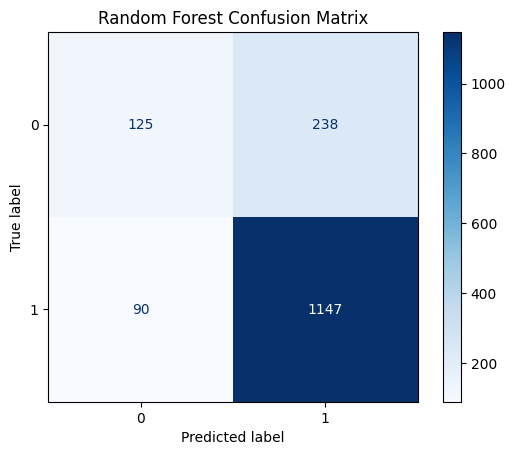

In [509]:
# Create the confusion matrix for the Random Forest
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

# Display the confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=cm_rf
).plot(cmap="Blues")

# Add a title
plt.title("Random Forest Confusion Matrix")

# Save the plot to the project's images folder
plt.savefig(
    "../images/Random Forest Confusion Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

# Show the plot
plt.show()

### 4.5 Training Accuracy Check

In [510]:
# Generate predictions for the training dataset
y_train_pred_rf = random_forest_pipeline.predict(X_train_no_risk)

# Calculate training accuracy
rf_train_accuracy = accuracy_score(y_train, y_train_pred_rf)

# Display training and testing accuracy
print(f"Random Forest Training Accuracy: {rf_train_accuracy:.3f}")
print(f"Random Forest Testing Accuracy : {accuracy_rf:.3f}")

Random Forest Training Accuracy: 1.000
Random Forest Testing Accuracy : 0.795


In [511]:
print("Random Forest Model Summary")
print(f"Accuracy : {accuracy_rf:.3f}")
print(f"Precision: {precision_rf:.3f}")
print(f"Recall   : {recall_rf:.3f}")
print(f"F1-Score : {f1_rf:.3f}")
print(f"ROC-AUC  : {roc_auc_rf:.3f}")

Random Forest Model Summary
Accuracy : 0.795
Precision: 0.828
Recall   : 0.927
F1-Score : 0.875
ROC-AUC  : 0.816


### 4.6 Hyperparameter Tuning for Random Forest

In [512]:
# Import RandomForestClassifier if needed
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest preprocessor
random_forest_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

# Create the Random Forest pipeline
random_forest_pipeline = Pipeline(steps=[
    ("preprocessor", random_forest_preprocessor),
    ("classifier", RandomForestClassifier(random_state=42, n_jobs=-1))
])

# Define the hyperparameter grid
param_grid_rf = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 5, 10],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 5, 10],
    "classifier__max_features": ["sqrt", "log2"]
}

# Create the GridSearchCV object
rf_grid_search = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=param_grid_rf,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

# Train the different Random Forest combinations
rf_grid_search.fit(X_train_no_risk, y_train)

# Display the best hyperparameter combination
print("Best Parameters:")
print(rf_grid_search.best_params_)

# Display the best cross-validation ROC-AUC score
print(f"\nBest Cross-Validation ROC-AUC: {rf_grid_search.best_score_:.3f}")

c:\Users\mor23\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters:
{'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 10, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}

Best Cross-Validation ROC-AUC: 0.825


### 4.7 Evaluate the Tuned Random Forest

In [513]:
# Retrieve the best Random Forest model found by GridSearchCV
best_rf = rf_grid_search.best_estimator_

# Generate predictions for the testing dataset
y_pred_rf_tuned = best_rf.predict(X_test_no_risk)

# Generate predicted probabilities for the positive class
y_prob_rf_tuned = best_rf.predict_proba(X_test_no_risk)[:, 1]

# Calculate evaluation metrics
accuracy_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)
precision_rf_tuned = precision_score(y_test, y_pred_rf_tuned)
recall_rf_tuned = recall_score(y_test, y_pred_rf_tuned)
f1_rf_tuned = f1_score(y_test, y_pred_rf_tuned)
roc_auc_rf_tuned = roc_auc_score(y_test, y_prob_rf_tuned)

# Display the evaluation metrics
print(f"Accuracy : {accuracy_rf_tuned:.3f}")
print(f"Precision: {precision_rf_tuned:.3f}")
print(f"Recall   : {recall_rf_tuned:.3f}")
print(f"F1 Score : {f1_rf_tuned:.3f}")
print(f"ROC-AUC  : {roc_auc_rf_tuned:.3f}")

Accuracy : 0.799
Precision: 0.819
Recall   : 0.949
F1 Score : 0.879
ROC-AUC  : 0.828


### 4.8 Check for Overfitting

In [514]:
# Generate predictions for the training dataset
y_train_pred_rf_tuned = best_rf.predict(X_train_no_risk)

# Calculate training accuracy
rf_train_accuracy_tuned = accuracy_score(y_train, y_train_pred_rf_tuned)

# Display training and testing accuracy
print(f"Tuned Training Accuracy: {rf_train_accuracy_tuned:.3f}")
print(f"Tuned Testing Accuracy : {accuracy_rf_tuned:.3f}")

Tuned Training Accuracy: 0.833
Tuned Testing Accuracy : 0.799


### 4.9 Tuned Random Forest Classification Report

In [515]:
# Display the classification report for the tuned Random Forest
print("Tuned Random Forest Classification Report")

print(
    classification_report(
        y_test,
        y_pred_rf_tuned
    )
)

Tuned Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.62      0.29      0.39       363
           1       0.82      0.95      0.88      1237

    accuracy                           0.80      1600
   macro avg       0.72      0.62      0.64      1600
weighted avg       0.77      0.80      0.77      1600



### 4.10 Tuned Random Forest Confusion Matrix

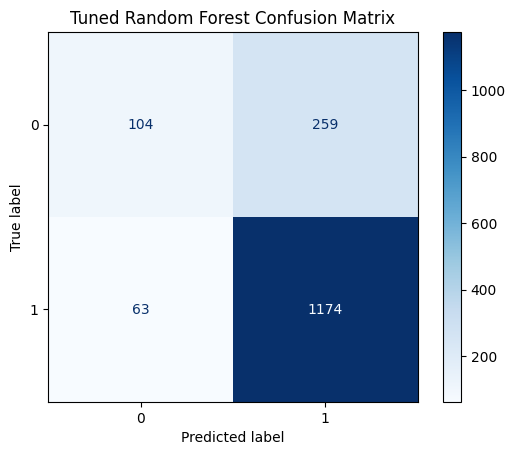

In [516]:
# Create the confusion matrix for the tuned Random Forest
cm_rf_tuned = confusion_matrix(
    y_test,
    y_pred_rf_tuned
)

# Display the confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=cm_rf_tuned
).plot(cmap="Blues")

# Add a title
plt.title("Tuned Random Forest Confusion Matrix")

# Save the plot to the project's images folder
plt.savefig(
    "../images/Tuned Random Forest Confusion Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

# Show the plot
plt.show()

### 4.11 Model Comparison Table

In [517]:
# Compare the main models side by side
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Tuned Decision Tree",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        accuracy_no_risk,
        accuracy_tree_tuned,
        accuracy_rf_tuned
    ],
    "Precision": [
        precision_no_risk,
        precision_tree_tuned,
        precision_rf_tuned
    ],
    "Recall": [
        recall_no_risk,
        recall_tree_tuned,
        recall_rf_tuned
    ],
    "F1-Score": [
        f1_no_risk,
        f1_tree_tuned,
        f1_rf_tuned
    ],
    "ROC-AUC": [
        roc_auc_no_risk,
        roc_auc_tree_tuned,
        roc_auc_rf_tuned
    ]
})

# Display the comparison table
model_comparison

# Sort models by ROC-AUC from highest to lowest
model_comparison.sort_values(by="ROC-AUC", ascending=False)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.813750,0.831802,0.951496,0.887632,0.839209
2,Tuned Random Forest,0.798750,0.819260,0.949070,0.879401,0.828092
1,Tuned Decision Tree,0.811875,0.846667,0.924010,0.883649,0.814910


### 4.12 Random Forest Model Summary

The Random Forest analysis demonstrated that the ensemble approach provided competitive predictive performance but did not outperform the Logistic Regression baseline. The untuned Random Forest achieved an accuracy of 79.5%, precision of 82.8%, recall of 92.7%, F1-score of 87.5%, and ROC-AUC of 81.6%. Although the model maintained strong recall for identifying patients who were readmitted, its overall performance was lower than Logistic Regression across the primary evaluation metrics.

The initial Random Forest also showed substantial overfitting, achieving 100% accuracy on the training data compared with 79.5% on the testing data. Hyperparameter tuning substantially improved this behavior. The tuned model reduced training accuracy to 83.3% while achieving 79.9% testing accuracy, narrowing the training-testing gap and indicating improved generalization. The tuned Random Forest achieved a recall of 94.9%, an F1-score of 87.9%, and a ROC-AUC of 82.8%. Therefore, tuning was beneficial primarily because it reduced overfitting and improved model stability, although the gains in test-set predictive performance were modest.

When the final models are compared using the feature set that excludes `readmission_risk_score`, Logistic Regression remains the strongest overall candidate. Logistic Regression achieved an accuracy of 81.4%, recall of 95.1%, F1-score of 88.8%, and ROC-AUC of 83.9%. The tuned Decision Tree achieved slightly higher precision, but Logistic Regression produced the highest accuracy, recall, F1-score, and ROC-AUC among the three final models.

Based on these results, **Logistic Regression should move forward as the leading final model candidate**. In addition to its slightly stronger predictive performance, Logistic Regression offers greater interpretability than Random Forest, which is particularly valuable when explaining the factors associated with hospital readmission. Random Forest nevertheless remains useful as a complementary model because its feature importance estimates can provide additional insight into which patient characteristics contribute most strongly to the prediction of readmission.


### 4.13 Random Forest Feature Importance

In addition to evaluating predictive performance, the Random Forest model can be used to examine the relative importance of the variables used to generate predictions. Feature importance measures how much each feature contributes to reducing classification uncertainty across the collection of decision trees.

Examining feature importance provides an additional perspective on the research question of which patient characteristics appear most informative for predicting hospital readmission. Because categorical variables were one-hot encoded during preprocessing, individual categories may appear as separate features in the resulting importance analysis.

These importance values should be interpreted as measures of predictive contribution within the Random Forest model rather than evidence of causal relationships. A variable receiving high importance indicates that the model relied more heavily on that feature when generating predictions, but it does not establish that the variable causes hospital readmission.


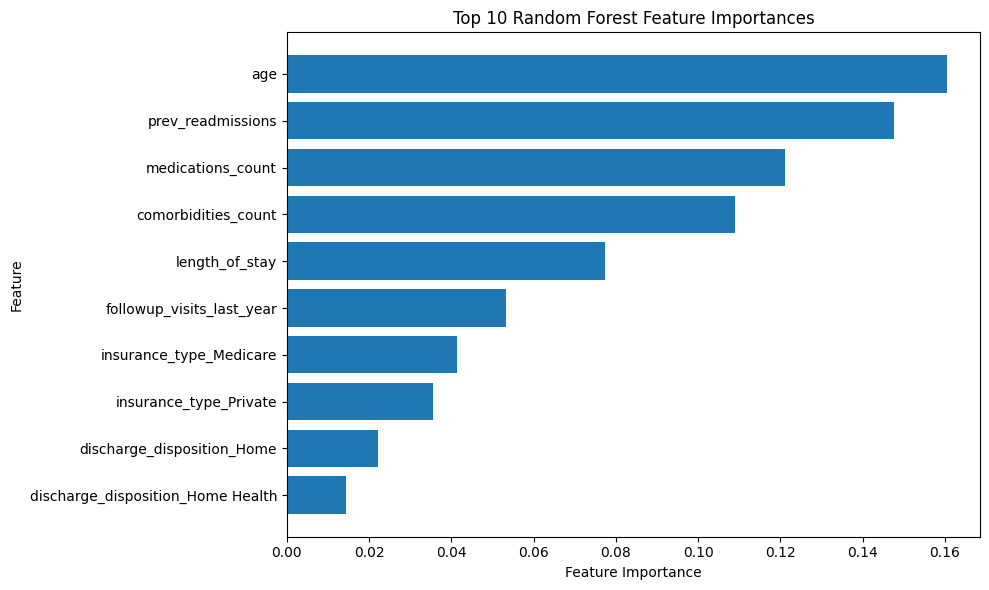

In [518]:
# Extract the fitted preprocessor and classifier
# from the tuned Random Forest pipeline
rf_preprocessor = best_rf.named_steps["preprocessor"]
rf_classifier = best_rf.named_steps["classifier"]

# Retrieve feature names after preprocessing
feature_names = rf_preprocessor.get_feature_names_out()

# Clean feature names for easier interpretation
feature_names = [
    name.replace("cat__", "").replace("remainder__", "")
    for name in feature_names
]

# Create a dataframe containing feature importance values
rf_feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_classifier.feature_importances_
})

# Sort features from most to least important
rf_feature_importance = rf_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display the 10 most important features
rf_feature_importance.head(10)

# Select the 10 most important features
top_features = (
    rf_feature_importance
    .head(10)
    .sort_values(by="Importance", ascending=True)
)

# Create the feature importance plot
plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()

# Save the figure
plt.savefig(
    "../images/Random Forest Feature Importances.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 4.14 Interpretation: Random Forest Feature Importance

The Random Forest feature importance analysis shows that the model relies most heavily on a relatively small group of patient and hospitalization characteristics when generating readmission predictions. The highest-ranked variables should therefore be viewed as the features containing the greatest predictive information within the fitted Random Forest model.

The feature importance results complement the exploratory analysis by providing a model-based perspective on which variables are most useful for distinguishing between patients who are and are not readmitted. Rather than considering each variable independently, the Random Forest evaluates these features across many decision trees and can capture nonlinear relationships and interactions that may not have been apparent from the exploratory analysis alone.

These findings should not be interpreted as evidence that the highest-ranked variables directly cause hospital readmission. Random Forest feature importance measures how useful a feature was for generating predictions within this particular model and dataset. Consequently, the results are most appropriately interpreted as indicators of predictive relevance rather than causal or clinical effects.

The feature importance analysis also provides useful context for the final model comparison. Although Random Forest did not outperform Logistic Regression overall, it remains valuable as a complementary analytical model because it provides insight into which variables contribute most strongly to prediction. These findings can therefore be compared with the Logistic Regression coefficients to determine whether the two modeling approaches identify similar patient characteristics as important predictors of readmission.


# 5. Final Model Interpretation

The model comparison identified Logistic Regression as the strongest overall candidate among the models evaluated. Although the differences in predictive performance were relatively modest, Logistic Regression achieved the highest overall combination of accuracy, recall, F1-score, and ROC-AUC while also providing greater interpretability than the tree-based alternatives.

Because interpretability is particularly valuable in a healthcare context, the next stage of the analysis examines the coefficients produced by the Logistic Regression model. These coefficients provide insight into the direction and relative strength of the relationships between patient characteristics and predicted hospital readmission.

To improve interpretability, the coefficients are also converted into **odds ratios**. An odds ratio greater than 1 indicates that higher values or the presence of a feature are associated with increased predicted odds of readmission, while an odds ratio below 1 indicates decreased predicted odds, holding the other variables in the model constant.

These relationships should be interpreted as predictive associations within this synthetic dataset rather than causal or clinical effects.

### 5.1 Extract Logistic Regression Coefficients

In [519]:
# Extract the fitted preprocessor and Logistic Regression classifier
logistic_preprocessor = logistic_pipeline_no_risk.named_steps["preprocessor"]
logistic_classifier = logistic_pipeline_no_risk.named_steps["classifier"]

# Retrieve feature names after preprocessing
feature_names_logistic = logistic_preprocessor.get_feature_names_out()

# Clean feature names for readability
feature_names_logistic = [
    name.replace("cat__", "").replace("num__", "").replace("remainder__", "")
    for name in feature_names_logistic
]

# Extract Logistic Regression coefficients
logistic_coefficients = logistic_classifier.coef_[0]

# Create a dataframe containing coefficients
logistic_feature_effects = pd.DataFrame({
    "Feature": feature_names_logistic,
    "Coefficient": logistic_coefficients
})

# Display coefficients
logistic_feature_effects

,Feature,Coefficient
0,age,0.242898
1,comorbidities_count,0.527887
2,length_of_stay,0.050634
3,medications_count,0.132226
4,followup_visits_last_year,0.063394
5,prev_readmissions,0.745439
6,season_Fall,0.127602
7,season_Spring,0.179378
8,season_Summer,0.059641
9,season_Winter,0.297065


### 5.2 Convert Coefficients to Odds Ratios

In [520]:
# Convert Logistic Regression coefficients to odds ratios
logistic_feature_effects["Odds Ratio"] = np.exp(
    logistic_feature_effects["Coefficient"]
)

# Calculate absolute coefficient magnitude for ranking
logistic_feature_effects["Absolute Coefficient"] = (
    logistic_feature_effects["Coefficient"].abs()
)

# Sort features by coefficient magnitude
logistic_feature_effects = logistic_feature_effects.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

# Display the most influential features
logistic_feature_effects.head(15)

,Feature,Coefficient,Odds Ratio,Absolute Coefficient
26,primary_diagnosis_Sepsis,0.795404,2.215337,0.795404
5,prev_readmissions,0.745439,2.107366,0.745439
18,primary_diagnosis_COPD,0.734883,2.085237,0.734883
23,primary_diagnosis_Influenza,-0.733545,0.480204,0.733545
27,primary_diagnosis_Stroke,0.666316,1.947051,0.666316
24,primary_diagnosis_Kidney Disease,0.576327,1.779491,0.576327
21,primary_diagnosis_Heart Failure,0.559235,1.749333,0.559235
20,primary_diagnosis_Fracture,-0.549151,0.577440,0.549151
1,comorbidities_count,0.527887,1.695347,0.527887
28,treatment_type_Conservative,0.462187,1.587543,0.462187


### Interpreting the Odds Ratios

The Logistic Regression coefficients describe the direction of each feature's relationship with predicted hospital readmission, while the odds ratios provide a more intuitive measure of the magnitude of that relationship.

* **Odds Ratio > 1:** associated with higher predicted odds of readmission.
* **Odds Ratio < 1:** associated with lower predicted odds of readmission.
* **Odds Ratio ≈ 1:** associated with relatively little change in predicted odds.

Because the numerical variables were standardized using `StandardScaler`, the odds ratios for continuous numerical features represent the change in predicted odds associated with approximately a **one-standard-deviation increase** in that variable, holding the other variables constant.

For categorical variables created through one-hot encoding, each coefficient represents the relationship associated with that category within the fitted model. Because the current encoder retains all categories, interpretation should consider the categorical coefficients collectively rather than treating any single dummy coefficient as a simple comparison with an explicitly omitted reference category.

These relationships represent predictive associations within this synthetic dataset and should not be interpreted as causal or clinically validated effects.


### 5.3 Separate Positive and Negative Associations

In [521]:
# Identify features associated with higher predicted readmission odds
positive_effects = logistic_feature_effects[
    logistic_feature_effects["Coefficient"] > 0
].sort_values(
    by="Coefficient",
    ascending=False
)

print("Features Associated with Higher Predicted Readmission Odds")
display(
    positive_effects[
        ["Feature", "Coefficient", "Odds Ratio"]
    ].head(10)
)

# Identify features associated with lower predicted readmission odds
negative_effects = logistic_feature_effects[
    logistic_feature_effects["Coefficient"] < 0
].sort_values(
    by="Coefficient",
    ascending=True
)

print("Features Associated with Lower Predicted Readmission Odds")
display(
    negative_effects[
        ["Feature", "Coefficient", "Odds Ratio"]
    ].head(10)
)

Features Associated with Higher Predicted Readmission Odds


,Feature,Coefficient,Odds Ratio
26,primary_diagnosis_Sepsis,0.795404,2.215337
5,prev_readmissions,0.745439,2.107366
18,primary_diagnosis_COPD,0.734883,2.085237
27,primary_diagnosis_Stroke,0.666316,1.947051
24,primary_diagnosis_Kidney Disease,0.576327,1.779491
21,primary_diagnosis_Heart Failure,0.559235,1.749333
1,comorbidities_count,0.527887,1.695347
28,treatment_type_Conservative,0.462187,1.587543
38,discharge_disposition_Rehab,0.415115,1.514545
33,insurance_type_Medicare,0.383153,1.466902


Features Associated with Lower Predicted Readmission Odds


,Feature,Coefficient,Odds Ratio
23,primary_diagnosis_Influenza,-0.733545,0.480204
20,primary_diagnosis_Fracture,-0.549151,0.577440
17,primary_diagnosis_Appendicitis,-0.406257,0.666139
22,primary_diagnosis_Hypertension,-0.391557,0.676004
19,primary_diagnosis_Diabetes,-0.318734,0.727069
25,primary_diagnosis_Pneumonia,-0.269236,0.763963
34,insurance_type_Private,-0.209259,0.811185
39,discharge_disposition_Skilled Nursing,-0.151505,0.859413


### 5.4 Visualize the Strongest Logistic Regression Effects

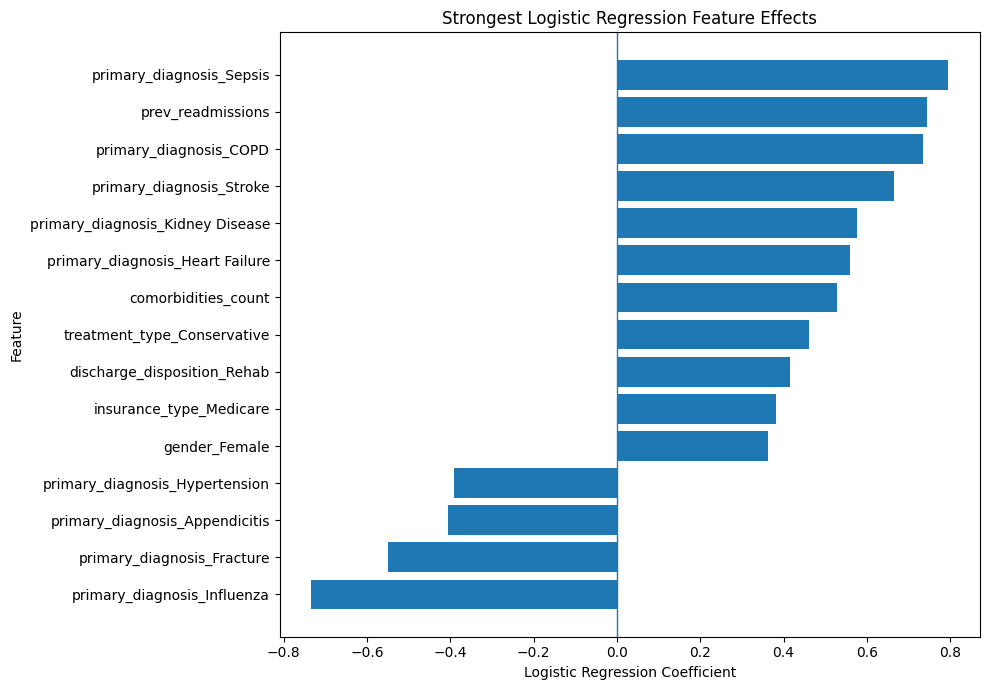

In [522]:
# Select the strongest Logistic Regression coefficients
top_logistic_features = (
    logistic_feature_effects
    .head(15)
    .sort_values(by="Coefficient")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_logistic_features["Feature"],
    top_logistic_features["Coefficient"]
)

# Add reference line at zero
plt.axvline(0, linewidth=1)

plt.title("Strongest Logistic Regression Feature Effects")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.tight_layout()

# Save the figure
plt.savefig(
    "../images/Logistic Regression Feature Effects.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 5.5 Interpretation: Logistic Regression Feature Effects

The Logistic Regression analysis provides additional insight into both the direction and relative strength of the relationships between patient characteristics and predicted hospital readmission.

The strongest positive associations were observed for primary_diagnosis_Sepsis, prev_readmissions, primary_diagnosis_COPD, primary_diagnosis_Stroke, primary_diagnosis_Kidney Disease, primary_diagnosis_Heart Failure, and comorbidities_count. These variables were associated with higher predicted odds of readmission after accounting for the other variables included in the model. Additional positive associations were also observed for treatment_type_Conservative, discharge_disposition_Rehab, and insurance_type_Medicare.

Conversely, primary_diagnosis_Influenza, primary_diagnosis_Fracture, primary_diagnosis_Appendicitis, primary_diagnosis_Hypertension, primary_diagnosis_Diabetes, primary_diagnosis_Pneumonia, insurance_type_Private, and discharge_disposition_Skilled Nursing showed the strongest negative associations, indicating lower predicted odds of readmission within the fitted model.

The most influential numerical predictors should be interpreted carefully because the numerical variables were standardized before model fitting. As a result, each coefficient for a numerical feature represents the change in predicted log-odds associated with approximately a one-standard-deviation increase in that variable, holding the other variables constant.

These results provide a useful complement to the Random Forest feature importance analysis. While Random Forest identifies which variables contribute most strongly to prediction, Logistic Regression additionally indicates whether those relationships are positive or negative. The consistency between the two modeling approaches helps identify patient characteristics that appear to contain particularly useful predictive information. However, because the dataset is synthetic and the analysis is observational, these associations should not be interpreted as causal or clinically validated relationships.

## 6. Research Question Findings

### 6.1 Which patient characteristics are most strongly associated with readmission?

The analysis suggests that previous readmissions, comorbidity burden, and several primary diagnosis categories are the clearest predictors of readmission risk. Patients with a history of prior readmissions and patients with more comorbidities consistently show higher readmission probability in both the exploratory analysis and the Logistic Regression model. In particular, the strongest positive model associations were observed for primary_diagnosis_Sepsis, prev_readmissions, primary_diagnosis_COPD, primary_diagnosis_Stroke, primary_diagnosis_Kidney Disease, and primary_diagnosis_Heart Failure.

### 6.2 Does length of stay influence readmission?

Length of stay appears to play a smaller role than patient history and diagnosis. In the correlation analysis, length_of_stay showed only a modest relationship with the target variable, and in the Logistic Regression model its coefficient was relatively small compared with the strongest predictors. This suggests that hospital stay duration may contribute some predictive value, but it is not the dominant driver of readmission risk in this dataset.

### 6.3 How do previous readmissions relate to future readmission?

Previous readmissions are one of the most important predictors in the analysis. The Logistic Regression model assigns a strong positive coefficient to prev_readmissions, and the feature appears near the top of the coefficient ranking. This indicates that patients with a history of prior readmissions are substantially more likely to be readmitted again, which is consistent with the exploratory findings and with clinical intuition.

### 6.4 Are diagnoses or clinical conditions associated with higher readmission?

Several diagnosis categories are associated with higher predicted readmission odds, especially Sepsis, COPD, Stroke, Kidney Disease, and Heart Failure. By contrast, categories such as Influenza, Fracture, Appendicitis, Hypertension, Diabetes, and Pneumonia are associated with lower predicted odds of readmission in the fitted model. These results should be interpreted as model-based associations within the synthetic dataset rather than clinical conclusions.

### 6.5 Which variables are most informative for prediction?

The modeling results indicate that the most informative variables are those related to prior utilization, overall patient complexity, and clinical diagnosis. The Random Forest feature-importance analysis provides a complementary view of this pattern by identifying which variables most strongly reduce classification uncertainty across the trees. Taken together, the exploratory analysis and the predictive models suggest that readmission risk is driven more by patient history and illness burden than by any single hospital stay characteristic.

### 6.6 Overall Findings

Overall, the analysis shows that hospital readmission is associated with a combination of patient history, clinical complexity, and diagnosis category. The strongest and most consistent signals across the project are previous readmissions, comorbidities, and several high-severity diagnoses. By comparison, length of stay appears to be a weaker standalone predictor.

The final model comparison supports Logistic Regression without `readmission_risk_score` as the strongest overall candidate because it balances predictive performance and interpretability. This makes it the most appropriate model to carry forward for the final interpretation and for any future discussion of practical use in a healthcare setting.

### 6.7 Precision-Recall and Average Precision Comparison

Because the target variable is imbalanced, additional evaluation was performed using Precision-Recall (PR) curves and Average Precision (AP).

A Precision-Recall curve illustrates the tradeoff between precision and recall across different classification thresholds. This is particularly useful for evaluating the model's ability to identify the positive class (`readmitted = 1`) without relying on a single classification threshold.

Average Precision summarizes the Precision-Recall curve into a single value. Higher Average Precision indicates that a model is better able to maintain precision while identifying a larger proportion of positive cases.

The three final candidate models—Logistic Regression, tuned Decision Tree, and tuned Random Forest—are compared using the same held-out testing dataset.

In [523]:
# Import Precision-Recall evaluation functions
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

# Generate predicted probabilities for each final model
y_prob_logistic = logistic_pipeline_no_risk.predict_proba(
    X_test_no_risk
)[:, 1]

y_prob_tree = best_tree.predict_proba(
    X_test_no_risk
)[:, 1]

y_prob_rf = best_rf.predict_proba(
    X_test_no_risk
)[:, 1]

# Calculate Average Precision for each model
ap_logistic = average_precision_score(
    y_test,
    y_prob_logistic
)

ap_tree = average_precision_score(
    y_test,
    y_prob_tree
)

ap_rf = average_precision_score(
    y_test,
    y_prob_rf
)

# Display Average Precision scores
print("Average Precision Scores")
print(f"Logistic Regression  : {ap_logistic:.3f}")
print(f"Tuned Decision Tree  : {ap_tree:.3f}")
print(f"Tuned Random Forest  : {ap_rf:.3f}")

Average Precision Scores
Logistic Regression  : 0.941
Tuned Decision Tree  : 0.929
Tuned Random Forest  : 0.938


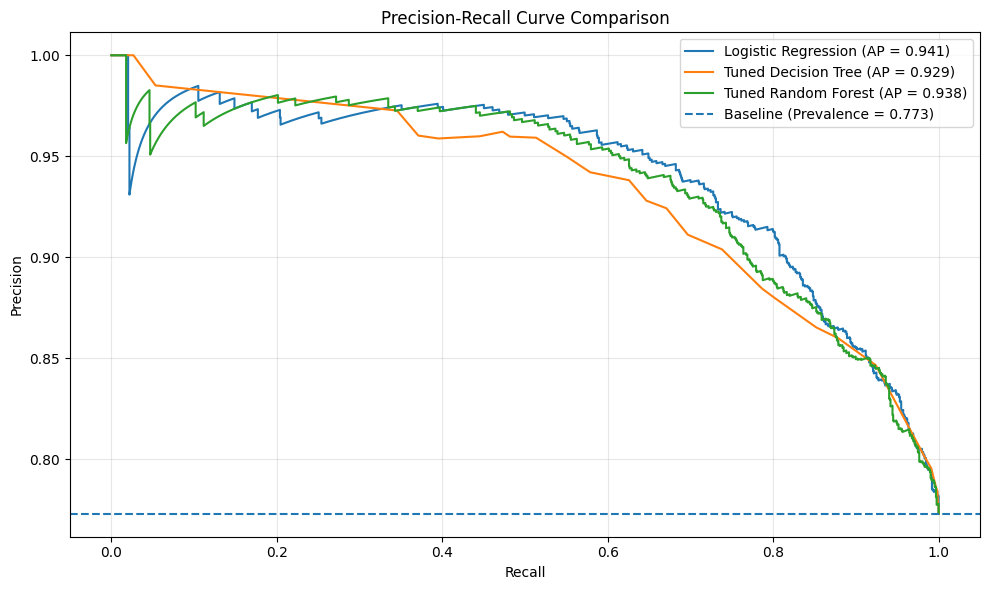

In [524]:
# Calculate Precision-Recall curves
precision_logistic, recall_logistic, _ = precision_recall_curve(
    y_test,
    y_prob_logistic
)

precision_tree, recall_tree, _ = precision_recall_curve(
    y_test,
    y_prob_tree
)

precision_rf, recall_rf, _ = precision_recall_curve(
    y_test,
    y_prob_rf
)

# Create the Precision-Recall comparison plot
plt.figure(figsize=(10, 6))

plt.plot(
    recall_logistic,
    precision_logistic,
    label=f"Logistic Regression (AP = {ap_logistic:.3f})"
)

plt.plot(
    recall_tree,
    precision_tree,
    label=f"Tuned Decision Tree (AP = {ap_tree:.3f})"
)

plt.plot(
    recall_rf,
    precision_rf,
    label=f"Tuned Random Forest (AP = {ap_rf:.3f})"
)

# Add the positive-class prevalence as a baseline
positive_rate = y_test.mean()

plt.axhline(
    y=positive_rate,
    linestyle="--",
    label=f"Baseline (Prevalence = {positive_rate:.3f})"
)

# Format the plot
plt.title("Precision-Recall Curve Comparison")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

# Save the figure
plt.savefig(
    "../images/Precision Recall Curve Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [525]:
# Add Average Precision to the final model comparison
model_comparison["Average Precision"] = [
    ap_logistic,
    ap_tree,
    ap_rf
]

# Display updated model comparison
model_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Average Precision
0,Logistic Regression,0.814,0.832,0.951,0.888,0.839,0.941
1,Tuned Decision Tree,0.812,0.847,0.924,0.884,0.815,0.929
2,Tuned Random Forest,0.799,0.819,0.949,0.879,0.828,0.938


### Interpretation: Precision-Recall Analysis

The Precision-Recall analysis provides an additional comparison of the three final models by evaluating their ability to identify readmitted patients across a range of classification thresholds.

Logistic Regression achieved the highest Average Precision at 0.941, followed closely by the tuned Random Forest at 0.938 and the tuned Decision Tree at 0.929. The positive class represents the majority of observations in the dataset, with approximately 77.3% of patients classified as readmitted. Therefore, the relatively high Average Precision values should be interpreted in relation to this baseline prevalence rather than considered in isolation.

All three models achieved Average Precision values above the positive-class prevalence baseline, indicating that each model provides useful ranking ability beyond simply reflecting the underlying class distribution. However, Logistic Regression produced the highest Average Precision, indicating that it maintained the strongest overall balance between precision and recall across classification thresholds.

These findings are consistent with the earlier model comparison. Logistic Regression achieved the highest accuracy (0.814), recall (0.951), F1-score (0.888), ROC-AUC (0.839), and Average Precision (0.941) among the three final models. The tuned Decision Tree achieved the highest precision (0.847), while the tuned Random Forest produced performance close to Logistic Regression on recall and Average Precision but did not surpass it overall.

The Precision-Recall analysis therefore strengthens the evidence supporting Logistic Regression as the preferred final model. Its combination of high recall, strong Average Precision, competitive precision, and greater interpretability provides the best overall balance for the objectives of this project.


# 7. Final Model Selection and Recommendations

### 7.1 Final Model Selection

Three classification approaches were evaluated during the predictive modeling phase: Logistic Regression, Decision Tree, and Random Forest. Hyperparameter tuning was also applied to the tree-based models to reduce overfitting and improve generalization.

Among the final models evaluated using the feature set that excludes `readmission_risk_score`, Logistic Regression produced the strongest overall performance:

| Model | Accuracy | Precision | Recall | F1-Score | ROC-AUC | Average Precision |
|---|---:|---:|---:|---:|---:|---:|
| **Logistic Regression** | **0.814** | 0.832 | **0.951** | **0.888** | **0.839** | **0.941** |
| Tuned Decision Tree | 0.812 | **0.847** | 0.924 | 0.884 | 0.815 | 0.929 |
| Tuned Random Forest | 0.799 | 0.819 | 0.949 | 0.879 | 0.828 | 0.938 |

Although the differences between the models are relatively modest, Logistic Regression achieved the highest accuracy, recall, F1-score, ROC-AUC, and Average Precision. The tuned Decision Tree produced slightly higher precision, while the tuned Random Forest achieved recall and Average Precision close to Logistic Regression but lower overall performance.

Based on these results, **Logistic Regression is selected as the preferred final model**.

### 7.2 Rationale for Model Selection

Predictive performance alone was not the only consideration in selecting the final model. Logistic Regression also provides substantially greater interpretability than the tree-based alternatives.

This interpretability allows the analysis to identify both the direction and relative magnitude of associations between patient characteristics and predicted readmission risk. For example, the model identified Sepsis, previous readmissions, COPD, Stroke, Kidney Disease, Heart Failure, and comorbidity burden as important positive predictors of readmission.

This ability to explain the model's predictions is particularly valuable in healthcare applications, where understanding why a patient may be classified as high risk can be as important as the prediction itself.

The model also maintains a high recall of approximately **95.1%** for the readmitted class. Within the context of this project, this means that the model successfully identifies most patients who experience readmission in the test dataset.

### 7.3 Role of the Alternative Models

Although Logistic Regression was selected as the preferred model, the Decision Tree and Random Forest analyses provided important complementary information.

The unrestricted Decision Tree demonstrated the risk of overfitting, achieving perfect training accuracy but substantially lower testing performance. Hyperparameter tuning significantly reduced this problem and produced a model with much better generalization.

Random Forest similarly demonstrated substantial initial overfitting. Tuning reduced the training-testing performance gap and improved model stability. Although Random Forest did not outperform Logistic Regression, its feature-importance analysis provided an additional perspective on which patient characteristics contributed most strongly to prediction.

Together, these models strengthened the analysis by showing that the final model selection was based on comparison across multiple modeling approaches rather than reliance on a single algorithm.

### 7.4 Practical Implications

The results suggest that information related to **previous healthcare utilization, patient comorbidity burden, and primary diagnosis** may be particularly useful when identifying patients at elevated risk of hospital readmission.

In a real healthcare setting, a predictive model based on these characteristics could potentially support discharge planning by helping identify patients who may benefit from additional follow-up, care coordination, medication review, or other post-discharge support.

However, the model developed in this project should not be used for clinical decision-making. The dataset is synthetic, and the relationships identified have not been externally or clinically validated.

### 7.5 Limitations of the Predictive Modeling

Several limitations should be considered when interpreting the modeling results.

First, the dataset is synthetic and may not accurately reproduce the complexity, variability, and relationships found in real patient populations.

Second, the target variable is imbalanced, with substantially more readmitted patients than non-readmitted patients. As a result, the models generally perform better at identifying readmissions than identifying patients who are not readmitted.

Third, several potentially important clinical predictors are unavailable, including laboratory measurements, detailed medical histories, socioeconomic information, physician documentation, and other indicators of disease severity.

Finally, although `readmission_risk_score` was excluded from the final model because of uncertainty regarding its construction and potential for data leakage, the absence of documentation prevents determining conclusively whether the feature contains inappropriate future information.

### 7.6 Recommendations for Future Work

Future analysis could strengthen the project by:

* Evaluating the models using additional data from independent patient populations.
* Investigating techniques for addressing class imbalance.
* Evaluating alternative probability thresholds based on the relative consequences of false-positive and false-negative predictions.
* Incorporating additional clinical, socioeconomic, and healthcare-utilization variables.
* Evaluating model calibration to determine whether predicted probabilities accurately reflect observed readmission rates.
* Examining model fairness and performance across patient subgroups.
* Comparing feature importance and coefficient patterns across additional modeling approaches.

Overall, the modeling results demonstrate that meaningful readmission predictions can be generated without relying on the potentially problematic `readmission_risk_score` variable. Logistic Regression provides the strongest combination of predictive performance, generalization, and interpretability among the models evaluated and is therefore selected as the preferred final model for this project.


## Conclusion

This project investigated the factors associated with hospital readmission and evaluated whether patient demographic and clinical characteristics could be used to predict readmission outcomes. Through exploratory data analysis and supervised machine learning, the analysis identified several meaningful patterns within the synthetic healthcare dataset and demonstrated how these relationships can be incorporated into predictive models.

The exploratory analysis showed that readmission risk was most strongly associated with indicators of patient history and clinical complexity. Previous hospital readmissions and comorbidity burden emerged as particularly important variables, while several primary diagnosis categories—including Sepsis, COPD, Stroke, Kidney Disease, and Heart Failure—were associated with higher predicted odds of readmission in the Logistic Regression model. In comparison, length of stay demonstrated a weaker relationship with readmission, suggesting that patient history and clinical condition may provide more predictive information than the duration of an individual hospitalization.

Three classification approaches were evaluated: Logistic Regression, Decision Tree, and Random Forest. The initial tree-based models demonstrated substantial overfitting, which was reduced through hyperparameter tuning and cross-validation. Although the tuned Decision Tree and Random Forest models produced competitive results, Logistic Regression provided the strongest overall performance. Using the feature set that excluded `readmission_risk_score`, Logistic Regression achieved an accuracy of 81.4%, recall of 95.1%, F1-score of 88.8%, ROC-AUC of 83.9%, and Average Precision of 94.1%.

The evaluation of `readmission_risk_score` was an important methodological consideration. Because the feature's construction was undocumented, its inclusion presented a potential risk of data leakage. Removing the variable resulted in only a minimal change in predictive performance while preserving strong recall and overall model discrimination. The final model therefore excludes the risk score, providing a more conservative and defensible modeling approach based on patient characteristics that can be more clearly interpreted.

Logistic Regression was selected as the preferred final model not only because of its predictive performance but also because of its interpretability. Examination of model coefficients and odds ratios provided insight into the direction and relative strength of associations between patient characteristics and predicted readmission risk. Random Forest feature importance provided a complementary perspective by identifying variables that contributed most strongly to prediction.

Overall, the project demonstrates that machine learning can identify meaningful patterns associated with hospital readmission and that strong predictive performance can be achieved without relying on the potentially problematic `readmission_risk_score` feature. However, because the dataset is synthetic, the results should not be interpreted as clinically validated relationships or used for clinical decision-making. Future work should evaluate these methods using real-world healthcare data, examine model performance across patient subgroups, assess probability calibration and classification thresholds, and further investigate approaches for addressing class imbalance.
